# Experiment 2: data parsing, analyses, and proof-of-concept solution-driven models

In [2]:
import numpy as np
import scipy 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import random
import os
import pickle
import glob 
import itertools
import re
#from statannotations.Annotator import Annotator
import json
from scipy.stats import ttest_rel, wilcoxon, ttest_ind, ranksums
from statsmodels.stats.proportion import proportions_ztest
from collections import Counter
import ast
from collections import deque
import matplotlib.cm as cm
from matplotlib import gridspec
import matplotlib.patches as patches
import math
import string
from copy import deepcopy
import heapq
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
from patsy import dmatrix, build_design_matrices  # <- key import
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pingouin
from matplotlib.collections import PolyCollection
from scipy import stats
from scipy.special import softmax
import arviz as az
from numpyro.infer import log_likelihood



figpath = os.path.join("fig")
fitspath = os.path.join("model_traces")
data_savepath = os.path.join("data")
datapath = os.path.join("..","experiment","data", "exp2")

experiment_names = ["exp2color","exp2visualsearch"]
exp_conds = [0,1] # 0 is easy, 1 is hard (either colorhover or visualsearch)

In [3]:
# Helper functions for parsing JSON entries

def parse_list_or_array_string(x):
    if not isinstance(x, str):
        return x

    s = x.strip()

    # Only try to parse bracketed structures
    if not s.startswith("["):
        return x

    # Case 1: valid Python literal, e.g. "[1, 2, 3]" or "[[1, 2], [3, 4]]"
    try:
        return ast.literal_eval(s)
    except (SyntaxError, ValueError):
        pass

    # Case 2: NumPy-style array string, e.g. "[[ 0  1  3]\n [ 2  4  5]]"
    try:
        arr = np.loadtxt(s.replace("[", "").replace("]", "").splitlines())
        return arr.astype(int).tolist()
    except Exception:
        return x  # leave unchanged if parsing fails

        
def equations_str_to_array(eq_str):
    """
    Convert a JSON string of [{x,y,z}, ...] to an (n,3) numpy array.
    Columns are ordered as [x, y, z].
    """
    data = json.loads(eq_str)   # list of dicts
    arr = np.array([[d["x"], d["y"], d["z"]] for d in data])
    return arr

def states_str_to_array(state_str, dtype=int):
    """
    Convert a string like '[0,0,0,1,...]' to a 1D numpy array.
    """
    return np.array(json.loads(state_str), dtype=dtype)

def parse_hover_log(log_str):
    """
    Convert a JSON string hover log into a list of dictionaries.
    """
    return json.loads(log_str)
import json
import pandas as pd

def total_hover_time_by_letter_and_equation(
    hover_log,
    letter_indices=range(13),    # 0–12
    equation_indices=range(8)    # 0–7
):
    letter_time = {i: 0.0 for i in letter_indices}
    equation_time = {i: 0.0 for i in equation_indices}

    for entry in hover_log:
        # be defensive: skip non-dicts
        if not isinstance(entry, dict):
            continue

        duration = entry.get("hover_duration_ms", 0.0) or 0.0
        li = entry.get("letter_idx")
        ei = entry.get("equation_idx")

        if li in letter_time:
            letter_time[li] += float(duration)

        if ei in equation_time:
            equation_time[ei] += float(duration)

    return letter_time, equation_time


def parse_and_summarize_hover_log(log_val):
    """
    log_val can be:
      - a JSON string like '[{...}, {...}]'
      - NaN / None
      - already a Python list of dicts
    Returns:
      hover_log_list, letter_time_dict, equation_time_dict
        1) parsed hover log (list of dicts)
        2) total hover time by letter_idx
        3) total hover time by equation_idx
    """
    # Treat NaN/None as empty log
    if log_val is None or (isinstance(log_val, float) and pd.isna(log_val)) or pd.isna(log_val):
        hover_log = []
        letter_time, equation_time = total_hover_time_by_letter_and_equation(hover_log)
        return hover_log, letter_time, equation_time

    # If already parsed
    if isinstance(log_val, list):
        hover_log = log_val
        letter_time, equation_time = total_hover_time_by_letter_and_equation(hover_log)
        return hover_log, letter_time, equation_time

    # Parse JSON string
    if isinstance(log_val, (str, bytes, bytearray)):
        hover_log = json.loads(log_val)
        letter_time, equation_time = total_hover_time_by_letter_and_equation(hover_log)
        return hover_log, letter_time, equation_time

    # Otherwise: unexpected type.
    hover_log = []
    letter_time, equation_time = total_hover_time_by_letter_and_equation(hover_log)
    return hover_log, letter_time, equation_time



def parse_and_summarize_visualsearch_hover_log(log_entry, n_eq=None, panel_names=("left", "right")):
    """
    Parse a single trial's hover log JSON string/dict and summarize:
      - panel hover total time by panel (ms)
      - equation/product hover total time by eq_index (ms)

    Parameters
    ----------
    log_entry : str | dict | None
        JSON like:
        {"t0":1204,"panel_hovers":[...],"product_hovers":[...]}
    n_eq : int | None
        Number of equations on that trial. If None, we infer from max eq_index seen (best-effort).
    panel_names : tuple[str]
        Panels to track explicitly (others will be tracked too, but these get guaranteed keys).

    Returns
    -------
    hover_parsed : dict | None
        Parsed JSON dict (or None if missing/bad).
    panel_time_ms : dict
        Mapping panel -> total ms.
    eq_time_ms : np.ndarray
        Vector of length n_eq with total ms per eq_index (float).
    """
    # --- handle missing / NaN
    if log_entry is None:
        hover_parsed = None
    elif isinstance(log_entry, float) and np.isnan(log_entry):
        hover_parsed = None
    elif isinstance(log_entry, dict):
        hover_parsed = log_entry
    else:
        s = str(log_entry).strip()
        if s == "" or s.lower() in {"nan", "none"}:
            hover_parsed = None
        else:
            try:
                hover_parsed = json.loads(s)
            except Exception:
                hover_parsed = None

    # --- initialize outputs
    panel_time_ms = {p: 0.0 for p in panel_names}
    eq_time_ms = np.zeros(int(n_eq) if n_eq is not None else 0, dtype=float)

    if not isinstance(hover_parsed, dict):
        return hover_parsed, panel_time_ms, eq_time_ms

    # helper to get duration in ms
    def _dur_ms(ev):
        d = ev.get("dur_ms", None)
        if d is None:
            ts = ev.get("t_start_ms", None)
            te = ev.get("t_end_ms", None)
            if ts is not None and te is not None:
                return float(te) - float(ts)
            return 0.0
        try:
            return float(d)
        except Exception:
            return 0.0

    # --- panel hovers
    panel_hovers = hover_parsed.get("panel_hovers", []) or []
    for ev in panel_hovers:
        if not isinstance(ev, dict):
            continue
        panel = ev.get("panel", None)
        if panel is None:
            continue
        dm = _dur_ms(ev)
        # track even unseen panels
        if panel not in panel_time_ms:
            panel_time_ms[panel] = 0.0
        panel_time_ms[panel] += dm

    # --- equation/product hovers
    prod_hovers = hover_parsed.get("product_hovers", []) or []
    # infer n_eq if needed
    if n_eq is None:
        max_idx = -1
        for ev in prod_hovers:
            if isinstance(ev, dict) and "eq_index" in ev:
                try:
                    max_idx = max(max_idx, int(ev["eq_index"]))
                except Exception:
                    pass
        eq_time_ms = np.zeros(max_idx + 1 if max_idx >= 0 else 0, dtype=float)

    for ev in prod_hovers:
        if not isinstance(ev, dict):
            continue
        if "eq_index" not in ev:
            continue
        try:
            idx = int(ev["eq_index"])
        except Exception:
            continue
        dm = _dur_ms(ev)
        # extend if indices exceed n_eq (just in case)
        if idx >= len(eq_time_ms):
            eq_time_ms = np.pad(eq_time_ms, (0, idx + 1 - len(eq_time_ms)), constant_values=0.0)
        eq_time_ms[idx] += dm

    return hover_parsed, panel_time_ms, eq_time_ms


# Only run the code block below if you collected new data files

In [4]:
# # Parse datafiles
# # data_cols = ["is_testtrial","submitted_eqs_indices","success"]
# gen_cols = ["experiment","equations","mturkID"]
# stim_cols = ["test_condition","condition","trial_idx","is_testtrial","state_group","state_idx","state"]
# resp_cols = ["time_exceeded","trial_elapsed_s","num_submitted_eqs","submitted_eqs_indices","use_cached_solution_path","invalid_rows","invalid_equations","missing_produced_ints","is_correct","bonus_trial"]
# process_cols = ["equation_hover_log"] # Only used for hard condition, colorhover.
# hover_col = "visualsearch_hover_log"
# summary_cols = ["gender","age","color_blindness","summary","strategy","comment","num_successful_trials","cumulative_bonus"]
# exp_count = -1
# exp_n_subjs_full = []
# for exp_idx, exp_name in enumerate(experiment_names):
#     for exp_cond in exp_conds:
#         # Parse datafiles
#         exp_count = exp_count+1
#         csv_files = glob.glob(os.path.join(datapath, "*.csv"))
#         n_subj = len(csv_files)
#         num_trials = 16
#         rejection_criterion = 8
#         max_bonus = 2
        
#         # Columns to save in data df.
#         data_cols = gen_cols + stim_cols + resp_cols
#         if(exp_name=="exp2visualsearch" and exp_cond==1): # Only used for hard condition, colorhover.
#             data_cols = data_cols + [hover_col]

#         # How many subjects, and which subjects are in this experiment group?
#         mturk_IDs = []
#         for subj in range(n_subj): 
#             # mturk_ID = csv_files[subj].split("\\")[-1][:-4]
#             mturk_ID = os.path.splitext(os.path.basename(csv_files[subj]))[0]
#             # read the csv file 
#             df_subj = pd.read_csv(csv_files[subj]) 
#             experiment_group_subj = df_subj["experiment"].iloc[0]
#             experiment_cond_subj = df_subj["test_condition"].iloc[0]
#             if(experiment_group_subj!=exp_name): # Subject not in this experiment group
#                 continue;
#             if(experiment_cond_subj!=exp_cond): # Subject did not do this experiment condition
#                 continue;
#             mturk_IDs.append(mturk_ID)
#         n_subj = len(mturk_IDs) # n_subj should count subjects in that particular group
#         if(n_subj==0):
#             continue;
#         print("# total subjects:",n_subj)
#         exp_n_subjs_full.append(n_subj)
#         # print(mturk_IDs)

#         for subj in range(n_subj): 
#             df_subj = pd.read_csv(os.path.join(datapath, mturk_IDs[subj]+".csv"))
#             trials_rows = np.where(0+np.isnan(df_subj["trial_idx"].to_numpy())==0)[0]
#             df_subj_trials = df_subj.iloc[trials_rows,:]
#             df_subjdata = df_subj_trials[data_cols]
#             df_subjdata["is_correct"] = df_subjdata["is_correct"].astype(int)
            
#             # Parse the JSON data columns
#             df_subjdata["equations"] = df_subjdata["equations"].apply(equations_str_to_array)
#             df_subjdata["state"] = df_subjdata["state"].apply(states_str_to_array)
#             df_subjdata["submitted_eqs_indices"] = df_subjdata["submitted_eqs_indices"].apply(states_str_to_array)
#             if(exp_cond==1):
#                 parsed = df_subjdata.apply(
#                     lambda r: parse_and_summarize_visualsearch_hover_log(
#                         r.get(hover_col, None),
#                         n_eq=len(r["equations"]) if isinstance(r["equations"], (list, np.ndarray)) else None,
#                         panel_names=("left", "right")
#                     ),
#                     axis=1
#                 )
#                 df_subjdata["hover_log_parsed"] = parsed.map(lambda x: x[0])
#                 df_subjdata["panel_time_ms_dict"] = parsed.map(lambda x: x[1])
#                 df_subjdata["eq_time_ms_vec"] = parsed.map(lambda x: x[2])
#                 # --- panel summary columns
#                 df_subjdata["panel_hover_ms_left"]  = df_subjdata["panel_time_ms_dict"].map(lambda d: float(d.get("left", 0.0)) if isinstance(d, dict) else 0.0)
#                 df_subjdata["panel_hover_ms_right"] = df_subjdata["panel_time_ms_dict"].map(lambda d: float(d.get("right", 0.0)) if isinstance(d, dict) else 0.0)
#                 df_subjdata["panel_hover_ms_total"] = df_subjdata["panel_hover_ms_left"] + df_subjdata["panel_hover_ms_right"]
#                 # --- equation hover totals + expand per-eq
#                 df_subjdata["eq_hover_ms_total"] = df_subjdata["eq_time_ms_vec"].map(lambda v: float(np.nansum(v)) if isinstance(v, np.ndarray) else 0.0)
#                 max_eq = int(df_subjdata["eq_time_ms_vec"].map(lambda v: len(v) if isinstance(v, np.ndarray) else 0).max())
#                 for k in range(max_eq):
#                     df_subjdata[f"eq_hover_ms_{k}"] = df_subjdata["eq_time_ms_vec"].map(
#                         lambda v, kk=k: float(v[kk]) if isinstance(v, np.ndarray) and kk < len(v) else 0.0
#                     )

#                 # (optional) drop intermediate objects if you don't want them
#                 # df_subjdata = df_subjdata.drop(columns=["panel_time_ms_dict", "eq_time_ms_vec"])


#             # Save demographic data and overall correctness
#             #print(df_subj[summary_cols].iloc[-1])
#             df_subjdata[summary_cols] = df_subj[summary_cols].iloc[-1]
#             # Aggregate across subjects
#             if(exp_count==0 and subj==0):
#                 df_allsubjs_trials = df_subjdata.copy()
#             else:
#                 df_allsubjs_trials = pd.concat([df_allsubjs_trials, df_subjdata])
            
# subj_global = pd.factorize(df_allsubjs_trials["mturkID"])[0]
# df_allsubjs_trials.insert(loc=2, column='subj_global', value=subj_global)
# df_allsubjs_trials['exp_cond'] = df_allsubjs_trials['experiment'].astype(str) + '_' + df_allsubjs_trials['test_condition'].astype(str)
# df_allsubjs_trials["is_einstellung_trial"] = (df_allsubjs_trials["state_group"]>1).astype(int)
# df_allsubjs_trials["num_invalid_equations"] = df_allsubjs_trials["invalid_rows"].apply(states_str_to_array).apply(len)
# df_allsubjs_trials["contains_invalid_equations"] = (df_allsubjs_trials["num_invalid_equations"]>0).astype(int)
# df_allsubjs_trials["num_missing_produced_ints"] = df_allsubjs_trials["missing_produced_ints"].apply(states_str_to_array).apply(len)
# df_allsubjs_trials["contains_missing_produced_ints"] = (df_allsubjs_trials["num_missing_produced_ints"]>0).astype(int)


# df_allsubjs_trials = df_allsubjs_trials[df_allsubjs_trials["exp_cond"]!="exp2visualsearch_0"]
# df_allsubjs_testtrials = df_allsubjs_trials[df_allsubjs_trials["is_testtrial"]==1]
# df_allsubjs_traintrials = df_allsubjs_trials[df_allsubjs_trials["is_testtrial"]==0]
# # For test trials, match by state_idx (remove trial randomization)
# df_allsubjs_testtrials.sort_values(by=["experiment","test_condition","subj_global","state_idx"], ascending=True, inplace=True)

# df_allsubjs_train_summary_raw = df_allsubjs_traintrials.groupby(["experiment","test_condition","exp_cond","subj_global"],as_index=False)[["num_submitted_eqs","is_correct", "use_cached_solution_path"]].mean()
# df_allsubjs_test_summary_raw = df_allsubjs_testtrials.groupby(["experiment","test_condition","exp_cond","subj_global"],as_index=False)[["num_submitted_eqs","is_correct", "use_cached_solution_path"]].mean()


In [5]:
# # Summary and strategy?
# demographics_df = (
#     df_allsubjs_trials[
#         ["mturkID", "test_condition", "subj_global"] + summary_cols
#     ]
#     .drop_duplicates(subset=["subj_global"]))

# gender_counts = (
#     demographics_df.groupby("test_condition")["gender"]
#       .value_counts(dropna=False)
#       .unstack(fill_value=0)
# )

# gender_counts

In [6]:
# # Bonus of participants
# # Summary and strategy?
# demographics_df = (
#     df_allsubjs_trials[
#         ["mturkID", "test_condition", "subj_global"] + summary_cols
#     ]
#     .drop_duplicates(subset=["subj_global"]))

# gender_counts = (
#     demographics_df.groupby("test_condition")["gender"]
#       .value_counts(dropna=False)
#       .unstack(fill_value=0)
# )

# gender_counts

# df_bonus= df_allsubjs_testtrials.groupby(["experiment","test_condition","mturkID","subj_global"],as_index=False)[["num_successful_trials","cumulative_bonus"]].mean()
# #df_bonus.loc[:,["mturkID","cumulative_bonus"]].to_csv("bonus.csv", index=False, header=False)

# df_allsubjs_trials = df_allsubjs_trials.reset_index(drop=True)

# # Strict definition of cached solution family: strict; sequence matters, no repetitions allowed. 
# allowed = [(6,), (2, 6), (0, 2, 6)]
# df_allsubjs_trials["use_cached_solution_path"] = (
#     df_allsubjs_trials["submitted_eqs_indices"]
#         .apply(tuple)
#         .isin(allowed)
#         .astype(int)
# )


# # #steps, (Einstellung - optimal) for each Einstellung trial
# no_penalty = (
#     (df_allsubjs_trials["state_group"] == 3) &
#     (df_allsubjs_trials["state_idx"] >= 14)
# ).astype(int)

# # Compute difference
# df_allsubjs_trials["solution_len_diff"] = (
#     df_allsubjs_trials["state_group"] -1 - no_penalty
# )
# # Clamp negatives to zero
# df_allsubjs_trials.loc[
#     df_allsubjs_trials["solution_len_diff"] < 0,
#     "solution_len_diff"
# ] = 0

# df_temp = df_allsubjs_trials.drop(columns='mturkID')
# df_temp.to_csv(os.path.join("data","exp2_data_noexclusion.csv"), index=False)


# # Remove people who had <0.7 test trial accuracy
# thres = 0.7
# exclude_subjs = np.where((df_allsubjs_test_summary_raw["is_correct"]<thres)==1)[0] 
# # Remove colorblind subjects
# exclude_subjs = np.concatenate((exclude_subjs,np.unique(df_allsubjs_testtrials[df_allsubjs_testtrials["color_blindness"]=="Yes"]["subj_global"])))
# exclude_subjs = np.array(list(set(exclude_subjs)))
# n_subj = len(df_allsubjs_train_summary_raw) - len(exclude_subjs)
# mask = df_allsubjs_trials["subj_global"].isin(exclude_subjs)
# df_allsubjs_trials = df_allsubjs_trials[~mask]
# print("# excluded subjects:",len(exclude_subjs))
# print(exclude_subjs)

# df_allsubjs_trials.drop(columns='mturkID').to_csv(os.path.join("data","exp2_data.csv"), index=False)


# Read saved data file instead

In [7]:
# Load saved data

df_allsubjs_trials = pd.read_csv(os.path.join("data","exp2_data.csv"))
#df_allsubjs_trials = df_allsubjs_trials.applymap(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else x)
n_subj = len(df_allsubjs_trials["subj_global"].unique())


for col in df_allsubjs_trials.columns:
    df_allsubjs_trials[col] = df_allsubjs_trials[col].map(parse_list_or_array_string)

In [8]:
# Recreate train and test dataframes.
df_allsubjs_testtrials = df_allsubjs_trials[df_allsubjs_trials["is_testtrial"]==1]
df_allsubjs_traintrials = df_allsubjs_trials[df_allsubjs_trials["is_testtrial"]==0]
df_allsubjs_traintrials["n_trials"] = 12
df_allsubjs_testtrials["n_trials"] = 16
# For test trials, match by state_idx (remove trial randomization)
df_allsubjs_testtrials.sort_values(by=["experiment","test_condition","subj_global","state_idx"], ascending=True, inplace=True)


# Summary and strategy?
summary_cols = ["gender","age","color_blindness","summary","strategy","comment","num_successful_trials","cumulative_bonus"]
demographics_df = (
    df_allsubjs_trials[
        ["test_condition", "subj_global"] + summary_cols
    ]
    .drop_duplicates(subset=["subj_global"]))
gender_counts = (
    demographics_df.groupby("test_condition")["gender"]
      .value_counts(dropna=False)
      .unstack(fill_value=0)
)
gender_counts

/var/folders/l2/2b4674qs2fd30bck37lz12740000gp/T/ipykernel_92006/4146742468.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_allsubjs_traintrials["n_trials"] = 12
/var/folders/l2/2b4674qs2fd30bck37lz12740000gp/T/ipykernel_92006/4146742468.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_allsubjs_testtrials["n_trials"] = 16
/var/folders/l2/2b4674qs2fd30bck37lz12740000gp/T/ipykernel_92006/4146742468.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

S

gender,Female,Male,Non-binary
test_condition,,,
0,57,49,4
1,56,53,1


In [9]:
# Remove nonsubmitted timeout trials

print(df_allsubjs_testtrials.shape)
df_allsubjs_testtrials = df_allsubjs_testtrials[df_allsubjs_testtrials['time_exceeded']<1]
print(df_allsubjs_testtrials.shape)

(3520, 52)
(3501, 52)


In [10]:
kept_cols = ["n_trials","num_submitted_eqs","is_correct", "trial_elapsed_s", "use_cached_solution_path", "num_successful_trials","contains_invalid_equations","contains_missing_produced_ints","num_invalid_equations","num_missing_produced_ints", "cumulative_bonus"]
df_allsubjs_train_summary = df_allsubjs_traintrials.groupby(["experiment","test_condition","exp_cond","subj_global"],as_index=False)[kept_cols].mean()
df_allsubjs_test_summary = df_allsubjs_testtrials.groupby(["experiment","test_condition","exp_cond","subj_global"],as_index=False)[kept_cols].mean()
df_allsubjs_test_summary_bystategroup = df_allsubjs_testtrials.groupby(["experiment","test_condition","exp_cond","subj_global","state_group"],as_index=False)[kept_cols].mean()
df_allsubjs_test_summary_byeinstellung = df_allsubjs_testtrials.groupby(["experiment","test_condition","exp_cond","subj_global","is_einstellung_trial"],as_index=False)[kept_cols].mean()
n_subjs_bycond = df_allsubjs_test_summary[["exp_cond"]].value_counts().to_numpy()

# Visualization

In [11]:

def annotate_violin_significance(
    ax,
    df,
    x, y,
    hue=None,
    test="t",             # "t" for one-sample t-test, "wilcoxon" for signed-rank
    mu=0,
    show="stars",         # "stars" or "p"
    fmt="%.4g",           # format for p-values if show="p"
    y_offset=0.02,        # vertical offset (in data units) above each violin
    min_height_pad=0.1,  # extra padding if the violin's top is close to max data
    font_size=10,
    zero_method="wilcox", # for Wilcoxon: "wilcox" (default) or "pratt"
    alternative="two-sided",
    width=0.8,            # fallback assumed total category width for dodge calc
    debug=False
):
    """
    Robustly annotate a seaborn violinplot (with or without hue) with significance vs. mu.

    The function finds the actual violin centers from PolyCollections, groups them
    by the nearest x-tick (category center), sorts left→right within each category,
    and aligns that order to the hue order used in the legend (or data) so labels
    sit on the correct violin.

    Parameters are the same as before; `width` is used only as a fallback when the
    center-detection doesn't return exactly one center per hue within a category.
    """

    def infer_levels(series):
        if isinstance(series.dtype, pd.CategoricalDtype):
            return list(series.cat.categories)
        vals = series.dropna().unique().tolist()
        try:
            return sorted(vals)
        except Exception:
            return vals

    def p_to_stars(p):
        if p < 1e-4: return "****"
        if p < 1e-3: return "***"
        if p < 1e-2: return "**"
        if p < 5e-2: return "*"
        return "n.s."

    # 1) Establish plotting order for x (from ticks) and hue (from legend if available)
    # X order from tick labels (most reliable wrt seaborn’s category order)
    xticks = np.array(ax.get_xticks())
    xticklabels = [t.get_text() for t in ax.get_xticklabels()]
    if any(lbl != "" for lbl in xticklabels) and len(xticklabels) == len(xticks):
        x_levels = xticklabels
        to_str = lambda v: str(v)
        # Map original df[x] values to their string form for matching
        # Build a resolver that maps string label -> original level if possible
        unique_x_vals = list(dict.fromkeys(df[x].dropna().tolist()))
        x_resolver = {str(v): v for v in unique_x_vals}
        x_levels_resolved = [x_resolver.get(lbl, lbl) for lbl in x_levels]
        x_levels = x_levels_resolved
    else:
        x_levels = infer_levels(df[x])
        # Assume categories laid out at 0..n-1 if ticks are missing
        xticks = np.arange(len(x_levels))

    # Hue order: try legend labels first (they reflect plotting order)
    if hue is None:
        hue_levels = [None]
    else:
        hue_levels = infer_levels(df[hue])
        try:
            _, leglabels = ax.get_legend_handles_labels()
            # Keep only labels that appear in the actual data (string match)
            data_hue_str = {str(v) for v in df[hue].dropna().unique().tolist()}
            leglabels = [lab for lab in leglabels if lab in data_hue_str]
            if len(leglabels) == len(hue_levels):
                # Map legend strings back to original dtype values when possible
                hue_map = {str(v): v for v in df[hue].dropna().unique().tolist()}
                hue_levels = [hue_map.get(lab, lab) for lab in leglabels]
        except Exception:
            pass

    n_x = len(x_levels)
    n_h = len(hue_levels)

    # 2) Detect violin centers & tops from PolyCollections and group by nearest x-tick
    polys = [c for c in ax.findobj(PolyCollection)]
    # Build structure: for each x-index, dict {center_x (rounded): top_y}
    centers_by_x = [dict() for _ in range(n_x)]

    for poly in polys:
        paths = getattr(poly, "get_paths", lambda: [])()
        if not paths:
            continue
        # Many violins are a single path; take the first
        verts = paths[0].vertices
        if verts.size == 0:
            continue
        cx = float(np.mean(verts[:, 0]))
        ty = float(np.max(verts[:, 1]))
        # Assign to nearest category tick
        x_idx = int(np.argmin(np.abs(xticks - cx)))
        # De-duplicate centers (two halves of a violin share same center)
        key = round(cx, 6)
        centers_by_x[x_idx][key] = max(ty, centers_by_x[x_idx].get(key, -np.inf))

    # 3) Build a mapping {(x_level, hue_level) -> (center_x, top_y)}
    center_map = {}
    top_map = {}
    for xi, xv in enumerate(x_levels):
        # Sorted center positions left→right actually present near this x
        present_centers = sorted(centers_by_x[xi].items(), key=lambda kv: kv[0])
        if len(present_centers) == n_h:
            # Perfect: map left→right to hue_levels order
            for hj, hv in enumerate(hue_levels):
                cx, ty = present_centers[hj]
                center_map[(xv, hv)] = cx
                top_map[(xv, hv)] = ty
        else:
            # Fallback: approximate dodge positions around the tick center
            if debug:
                print(f"[annotate_violin_significance] Fallback at x={xv}: "
                      f"found {len(present_centers)} centers, expected {n_h}.")
            tick_center = xticks[xi]
            # equally spaced within total width
            offsets = np.linspace(-width/2 + width/(2*n_h),
                                   width/2 - width/(2*n_h),
                                   n_h) if n_h > 1 else np.array([0.0])
            # Use global top from data (safer than violin height when falling back)
            ty_guess = df.loc[df[x] == xv, y].max()
            for hj, hv in enumerate(hue_levels):
                center_map[(xv, hv)] = tick_center + offsets[hj]
                top_map[(xv, hv)] = float(ty_guess)

    # 4) Run one-sample tests per (x,hue) and annotate exactly at that center
    global_y_max = float(np.nanmax(df[y].values))

    annotations = []
    for xv in x_levels:
        for hv in hue_levels:
            if hue is None:
                mask = (df[x] == xv)
            else:
                mask = (df[x] == xv) & (df[hue] == hv)
            group = df.loc[mask, y].dropna().values

            if group.size == 0:
                pval = np.nan
            else:
                if test.lower() in ["t", "ttest", "t-test", "onesample", "one-sample"]:
                    res = stats.ttest_1samp(group, popmean=mu, alternative=alternative)
                    pval = res.pvalue
                    bf10 = pingouin.bayesfactor_ttest(t=res.statistic, nx=len(group), paired=False)
                    print("Bayes Factor BF10:", bf10)
                elif test.lower() in ["wilcoxon", "signed-rank", "wilcox"]:
                    diffs = group - mu
                    if np.allclose(diffs, 0):
                        pval = 1.0
                    else:
                        res = stats.wilcoxon(diffs, zero_method=zero_method,
                                             alternative=alternative, method="auto")
                        pval = res.pvalue
                else:
                    raise ValueError("test must be 't' or 'wilcoxon'")

            annotations.append((xv, hv, pval))

    for xv, hv, pval in annotations:
        cx = center_map[(xv, hv)]
        ty = top_map[(xv, hv)]
        y_text = max(ty + y_offset, global_y_max + min_height_pad)

        if np.isnan(pval):
            label = "n/a"
        else:
            label = p_to_stars(pval) if show == "stars" else f"p = {fmt % pval}"

        ax.text(cx, y_text, label,
                ha="center", va="bottom", fontsize=font_size, clip_on=False)

    # Ensure room for labels
    ax.set_ylim(bottom=ax.get_ylim()[0],
                top=max(ax.get_ylim()[1], global_y_max + 0.08))

    return ax



import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from scipy import stats

def annotate_paired_violin_significance(
    ax,
    df,
    x, y,
    hue,
    id_col,                 # required: subject/ID column used to make pairs
    test="t",               # "t" (paired t) or "wilcoxon" (signed-rank)
    show="stars",           # "stars", "p", or "p_and_d"
    fmt="%.2g",             # p-value format when show="p" or show="p_and_d"
    d_fmt="%.2f",           # Cohen's dz format when show="p_and_d"
    y_offset=0.1,          # vertical offset above the taller violin (data units)
    min_height_pad=0.1,    # min padding over global max if needed
    zero_method="wilcox",   # Wilcoxon zero handling: "wilcox" (default) or "pratt"
    alternative="two-sided",
    compare_hues=None,      # tuple/list like ("6","10") to force comparison order
    bracket_width_pad=0.03, # small horizontal pad so bracket ends extend slightly past centers
    bracket_thickness=1.5,  # line width for the bracket
    cap_height=0.05,        # small vertical caps at ends of bracket
    font_size=10,           # label text size
):
    """
    For each x level, compare the two hue groups with a paired test and draw a bracket.

    Assumes exactly two hue levels per x (or specify `compare_hues`).
    Pairs are formed by matching rows with the same `id_col` within each (x, hue).

    Example:
      sns.violinplot(data=df, x="experiment", y="metric", hue="N_train", ax=ax, fill=False)
      annotate_paired_violin_significance(ax, df, x="experiment", y="metric",
                                          hue="N_train", id_col="Subject", test="wilcoxon")
    """

    # --- helpers ---
    def infer_levels(series):
        if isinstance(series.dtype, pd.CategoricalDtype):
            return list(series.cat.categories)
        vals = series.dropna().unique().tolist()
        try:
            return sorted(vals)
        except Exception:
            return vals

    def cohen_dz_paired(A, B):
        diff = np.asarray(A, dtype=float) - np.asarray(B, dtype=float)
        diff = diff[np.isfinite(diff)]
        if len(diff) < 2:
            return np.nan
        sd = np.std(diff, ddof=1)
        if sd == 0:
            return np.nan
        return np.mean(diff) / sd

    def p_to_stars(p):
        if p < 1e-4: return "****"
        if p < 1e-3: return "***"
        if p < 1e-2: return "**"
        if p < 5e-2: return "*"
        return "n.s."

    # Resolve plotting order to match seaborn's drawing order (x outer, hue inner)
    x_levels = infer_levels(df[x])
    hue_levels = infer_levels(df[hue])

    if compare_hues is None:
        if len(hue_levels) != 2:
            raise ValueError("Need exactly two hue levels or specify `compare_hues=(h1, h2)`.")
        compare_hues = (hue_levels[0], hue_levels[1])
    else:
        if len(compare_hues) != 2:
            raise ValueError("`compare_hues` must be a pair, e.g., ('A','B').")

    # Grab the violin bodies in the axes, in seaborn's draw order
    poly_bodies = [c for c in ax.collections if isinstance(c, PolyCollection)]
    n_expected = len(x_levels) * len(hue_levels)
    if len(poly_bodies) < n_expected:
        # Sometimes there are split artists; be defensive
        poly_bodies = poly_bodies[:n_expected]

    # Build a table of (center_x, top_y) for each (x_i, hue_j) in draw order
    centers = {}
    tops = {}
    k = 0
    for xi, xv in enumerate(x_levels):
        for hj, hv in enumerate(hue_levels):
            if k >= len(poly_bodies):
                continue
            poly = poly_bodies[k]
            k += 1
            # Each violin usually has a single path; take its center and top
            try:
                verts = poly.get_paths()[0].vertices
            except Exception:
                continue
            cx = np.mean(verts[:, 0])
            ty = np.max(verts[:, 1])
            centers[(xv, hv)] = cx
            tops[(xv, hv)] = ty

    # Global y range (for padding if violins touch the top)
    global_y_max = np.nanmax(df[y].values)

    # Compute paired tests per x level and annotate
    for xv in x_levels:
        # Form pairs by ID for the two hue levels at this x
        a_level, b_level = compare_hues

        gA = df.loc[(df[x] == xv) & (df[hue] == a_level), [id_col, y]].dropna()
        gB = df.loc[(df[x] == xv) & (df[hue] == b_level), [id_col, y]].dropna()

        if gA.empty or gB.empty:
            pval = np.nan
            dval = np.nan
        else:
            merged = pd.merge(gA, gB, on=id_col, suffixes=("__A", "__B"))
            A = merged[f"{y}__A"].values
            B = merged[f"{y}__B"].values
        
            if len(A) == 0:
                pval = np.nan
                dval = np.nan
            else:
                dval = cohen_dz_paired(A, B)
        
                if test.lower() in ["t", "ttest", "paired_t", "paired-t", "ttest_rel"]:
                    res = stats.ttest_rel(A, B, alternative=alternative)
                    pval = res.pvalue
                elif test.lower() in ["wilcoxon", "signed-rank", "wilcox"]:
                    if np.allclose(A - B, 0):
                        pval = 1.0
                    else:
                        res = stats.wilcoxon(
                            A, B,
                            zero_method=zero_method,
                            alternative=alternative,
                            method="auto"
                        )
                        pval = res.pvalue
                else:
                    raise ValueError("test must be 't' (paired t) or 'wilcoxon' (signed-rank)")

        # Compute bracket position using the plotted violin centers/tops
        if (xv, a_level) not in centers or (xv, b_level) not in centers:
            # Skip if we can't find both violins (e.g., missing group)
            continue

        x1 = centers[(xv, a_level)]
        x2 = centers[(xv, b_level)]
        topA = tops[(xv, a_level)]
        topB = tops[(xv, b_level)]
        y_bracket = max(topA, topB) + y_offset
        y_bracket = max(y_bracket, global_y_max + min_height_pad)

        # Draw bracket ( ┌───┐ style with small caps )
        x_left  = min(x1, x2) - bracket_width_pad
        x_right = max(x1, x2) + bracket_width_pad

        # horizontal bar
        ax.plot([x_left, x_right], [y_bracket, y_bracket],
                lw=bracket_thickness, color="black", clip_on=False)
        # small vertical caps
        ax.plot([x_left, x_left],   [y_bracket, y_bracket - cap_height],
                lw=bracket_thickness, color="black", clip_on=False)
        ax.plot([x_right, x_right], [y_bracket, y_bracket - cap_height],
                lw=bracket_thickness, color="black", clip_on=False)

        # Label
        if np.isnan(pval):
            label = "n/a"
        elif show == "stars":
            label = p_to_stars(pval)
        elif show == "p":
            label = f"p = {fmt % pval}"
        elif show == "p_and_d":
            p_txt = f"p = {fmt % pval}"
            d_txt = f"dᶻ = {d_fmt % dval}" if not np.isnan(dval) else "dᶻ = n/a"
            label = p_txt + "\n" + d_txt
        else:
            raise ValueError("show must be 'stars', 'p', or 'p_and_d'")

        ax.text((x_left + x_right) / 2.0,
                y_bracket + 0.005,
                label,
                ha="center", va="bottom",
                fontsize=font_size)

    # Make sure labels aren’t clipped
    ax.set_ylim(bottom=ax.get_ylim()[0],
                top=max(ax.get_ylim()[1], global_y_max + 0.08))

    return ax


In [12]:
import numpy as np
import pandas as pd
from scipy import stats
from matplotlib.collections import PathCollection, PolyCollection
import statsmodels.api as sm


def annotate_ind_violin_significance(
    ax,
    df,
    x, y,
    hue=None,
    comparisons=None,
    test="t",                  # "t", "ranksum", "logit_t", "perm", "binom_glm"
    paired=False,
    id_col=None,
    alternative="two-sided",
    show="p",                  # "stars", "p", or "p_and_d"
    fmt="%.3g",
    d_fmt="%.3f",              # NEW: Cohen's d formatting
    y_offset=0.03,
    cap_height=0.02,
    bracket_width_pad=0.08,
    bracket_thickness=1.5,
    font_size=10,
    color="black",
    debug=False,
    # probability-handling params
    prob_clip_eps=1e-6,
    perm_n=20000,
    perm_seed=0,
):
    def p_to_stars(p):
        if p < 1e-4: return "****"
        if p < 1e-3: return "***"
        if p < 1e-2: return "**"
        if p < 5e-2: return "*"
        return "n.s."

    def logit(p):
        p = np.asarray(p, float)
        p = np.clip(p, prob_clip_eps, 1 - prob_clip_eps)
        return np.log(p / (1 - p))

    # NEW: independent-groups Cohen's d
    def cohen_d_ind(A, B):
        A = np.asarray(A, dtype=float)
        B = np.asarray(B, dtype=float)
        A = A[np.isfinite(A)]
        B = B[np.isfinite(B)]

        if len(A) < 2 or len(B) < 2:
            return np.nan

        varA = np.var(A, ddof=1)
        varB = np.var(B, ddof=1)

        pooled_var = ((len(A) - 1) * varA + (len(B) - 1) * varB) / (
            len(A) + len(B) - 2
        )

        if pooled_var <= 0:
            return np.nan

        return (np.mean(A) - np.mean(B)) / np.sqrt(pooled_var)

    # NEW: paired-design Cohen's dz
    def cohen_dz_paired(A, B):
        diff = np.asarray(A, dtype=float) - np.asarray(B, dtype=float)
        diff = diff[np.isfinite(diff)]

        if len(diff) < 2:
            return np.nan

        sd = np.std(diff, ddof=1)
        if sd == 0:
            return np.nan

        return np.mean(diff) / sd

    def pval_perm_ind(A, B, alternative="two-sided", n=20000, seed=0):
        rng = np.random.default_rng(seed)
        A = np.asarray(A, float)
        B = np.asarray(B, float)
        obs = np.mean(A) - np.mean(B)
        pooled = np.concatenate([A, B])
        nA = len(A)
        count = 0

        chunk = 2000
        reps_done = 0
        while reps_done < n:
            m = min(chunk, n - reps_done)
            idx = np.tile(np.arange(len(pooled)), (m, 1))
            for i in range(m):
                rng.shuffle(idx[i])

            Aperm = pooled[idx[:, :nA]]
            Bperm = pooled[idx[:, nA:]]
            diffs = Aperm.mean(axis=1) - Bperm.mean(axis=1)

            if alternative == "two-sided":
                count += np.sum(np.abs(diffs) >= abs(obs))
            elif alternative == "greater":
                count += np.sum(diffs >= obs)
            elif alternative == "less":
                count += np.sum(diffs <= obs)
            else:
                raise ValueError("alternative must be 'two-sided', 'greater', or 'less'")

            reps_done += m

        return (count + 1) / (n + 1)

    def pval_binom_glm(pA, pB, nA, nB):
        """
        Treat each subject's P(use default solution) as one sample from a binomial
        distribution Binom(n_trials, p_i).
        """
        pA = np.asarray(pA, float)
        pB = np.asarray(pB, float)
        nA = np.asarray(nA, float)
        nB = np.asarray(nB, float)

        mA = np.isfinite(pA) & np.isfinite(nA) & (nA > 0)
        mB = np.isfinite(pB) & np.isfinite(nB) & (nB > 0)

        pA, nA = pA[mA], nA[mA]
        pB, nB = pB[mB], nB[mB]

        if len(pA) == 0 or len(pB) == 0:
            return np.nan

        p = np.concatenate([pA, pB])
        n = np.concatenate([nA, nB])
        X = sm.add_constant(np.concatenate([np.zeros(len(pA)), np.ones(len(pB))]))

        model = sm.GLM(p, X, family=sm.families.Binomial(), freq_weights=n)
        res = model.fit(disp=0)
        return float(res.pvalues[1])

    # x tick label -> position
    xticks = ax.get_xticks()
    xlabels = [t.get_text() for t in ax.get_xticklabels()]
    if len(xlabels) == 0:
        raise RuntimeError("No x tick labels found. Call after plotting.")

    x_to_pos = {str(lab): pos for lab, pos in zip(xlabels, xticks)}

    # spacing + y offsets
    cat_spacing = float(np.min(np.diff(np.sort(xticks)))) if len(xticks) >= 2 else 1.0
    ymin, ymax = ax.get_ylim()
    yrng = (ymax - ymin) if ymax > ymin else 1.0
    yoff = y_offset * yrng
    cap = cap_height * yrng
    xpad = bracket_width_pad * cat_spacing

    # centers[(x_label, hue_level)] -> x position on plot
    centers = {}
    if hue is None:
        for xl in x_to_pos:
            centers[(xl, None)] = x_to_pos[xl]
    else:
        # infer from stripplot/scatter points
        point_cols = [
            c for c in ax.collections
            if isinstance(c, PathCollection) and not isinstance(c, PolyCollection)
        ]

        all_offsets = []
        for pc in point_cols:
            offs = pc.get_offsets()
            if offs is not None and len(offs) > 0:
                all_offsets.append(np.asarray(offs))

        if len(all_offsets) == 0:
            raise RuntimeError(
                "No point offsets found. Need stripplot(..., dodge=True) before annotating."
            )

        all_offsets = np.vstack(all_offsets)

        x_tick_pos = np.array(list(x_to_pos.values()))
        x_tick_lab = np.array(list(x_to_pos.keys()))

        def nearest_tick_label(xp):
            return x_tick_lab[int(np.argmin(np.abs(x_tick_pos - xp)))]

        # hue levels from df; preserve OLD behavior
        hue_levels = df[hue].dropna().astype(str).unique().tolist()
        try:
            hue_levels = sorted(hue_levels)
        except Exception:
            pass

        if debug:
            print("xlabels:", xlabels)
            print("hue_levels:", hue_levels)

        by_x = {xl: [] for xl in x_to_pos.keys()}
        for xp, yp in all_offsets:
            xl = nearest_tick_label(float(xp))
            by_x[xl].append(float(xp))

        k = len(hue_levels)
        for xl, xs in by_x.items():
            xs = np.array(xs, dtype=float)

            if xs.size == 0:
                continue

            if xs.size < k:
                base = x_to_pos[xl]
                for i, h in enumerate(hue_levels):
                    centers[(xl, h)] = base + (
                        i - (k - 1) / 2.0
                    ) * (0.6 * cat_spacing / max(1, k - 1))
                continue

            mus = np.quantile(xs, np.linspace(0.1, 0.9, k))
            for _ in range(30):
                lab = np.argmin(np.abs(xs[:, None] - mus[None, :]), axis=1)
                new_mus = np.array([
                    xs[lab == j].mean() if np.any(lab == j) else mus[j]
                    for j in range(k)
                ])
                if np.allclose(new_mus, mus):
                    break
                mus = new_mus

            mus_sorted = np.sort(mus)
            for h, cx in zip(hue_levels, mus_sorted):
                centers[(xl, h)] = float(cx)

    # normalize comparisons to list of ((xA,hA),(xB,hB))
    if comparisons is None:
        raise ValueError("Provide comparisons.")

    comp_list = []
    if isinstance(comparisons, tuple) and len(comparisons) == 2 and hue is not None:
        h1, h2 = map(str, comparisons)
        for xl in x_to_pos.keys():
            comp_list.append(((xl, h1), (xl, h2)))
    else:
        comp_list = list(comparisons)

    def get_vals(x_level, h_level):
        m = (df[x].astype(str) == str(x_level))
        if hue is not None:
            m &= (df[hue].astype(str) == str(h_level))

        if not paired:
            return df.loc[m, y].dropna().to_numpy()
        else:
            if id_col is None:
                raise ValueError("paired=True requires id_col.")
            return df.loc[m, [id_col, y]].dropna()

    drawn = 0

    for (gA, gB) in comp_list:
        (xA, hA) = gA
        (xB, hB) = gB

        xA, xB = str(xA), str(xB)
        hA = None if hue is None else str(hA)
        hB = None if hue is None else str(hB)

        if (xA, hA) not in centers or (xB, hB) not in centers:
            if debug:
                print("SKIP missing centers:", (xA, hA), (xB, hB))
                print("Available centers:", sorted(centers.keys()))
            continue

        # data
        if not paired:
            A = get_vals(xA, hA)
            B = get_vals(xB, hB)

            if len(A) == 0 or len(B) == 0:
                if debug:
                    print("SKIP empty data:", (xA, hA, len(A)), (xB, hB, len(B)))
                continue

            topA, topB = np.max(A), np.max(B)

            # NEW: compute independent-groups d without changing test behavior
            dval = cohen_d_ind(A, B)

            # tests
            tl = test.lower()
            if tl in ["t", "ttest", "ttest_ind"]:
                pval = stats.ttest_ind(
                    A, B,
                    equal_var=False,
                    alternative=alternative
                ).pvalue

            elif tl in ["ranksum", "ranksums", "mw", "mannwhitney"]:
                pval = stats.mannwhitneyu(A, B).pvalue

            elif tl in ["logit_t", "logit", "logit-ttest"]:
                ZA, ZB = logit(A), logit(B)
                pval = stats.ttest_ind(
                    ZA, ZB,
                    equal_var=False,
                    alternative=alternative
                ).pvalue

                # Optional: report d on logit-transformed scale for logit tests.
                dval = cohen_d_ind(ZA, ZB)

            elif tl in ["perm", "permutation"]:
                pval = pval_perm_ind(
                    A, B,
                    alternative=alternative,
                    n=perm_n,
                    seed=perm_seed
                )

            elif tl in ["binom_glm", "binomial", "logistic"]:
                if "n_trials" not in df.columns:
                    raise ValueError("test='binom_glm' requires column 'n_trials'.")

                if hue is None:
                    A_n = df.loc[df[x].astype(str) == xA, "n_trials"].to_numpy()
                    B_n = df.loc[df[x].astype(str) == xB, "n_trials"].to_numpy()
                else:
                    A_n = df.loc[
                        (df[x].astype(str) == xA) &
                        (df[hue].astype(str) == hA),
                        "n_trials"
                    ].to_numpy()
                    B_n = df.loc[
                        (df[x].astype(str) == xB) &
                        (df[hue].astype(str) == hB),
                        "n_trials"
                    ].to_numpy()

                pval = pval_binom_glm(A, B, A_n, B_n)

            else:
                raise ValueError(
                    "test must be one of: 't', 'ranksum', 'logit_t', 'perm', 'binom_glm'"
                )

        else:
            dA = get_vals(xA, hA)
            dB = get_vals(xB, hB)

            merged = pd.merge(
                dA.rename(columns={y: "A"}),
                dB.rename(columns={y: "B"}),
                on=id_col,
                how="inner"
            )

            if merged.empty:
                continue

            A = merged["A"].to_numpy()
            B = merged["B"].to_numpy()

            topA, topB = np.max(A), np.max(B)

            # NEW: paired d_z
            dval = cohen_dz_paired(A, B)

            tl = test.lower()
            if tl in ["t", "ttest", "ttest_rel"]:
                pval = stats.ttest_rel(A, B, alternative=alternative).pvalue

            elif tl in ["ranksum", "wilcoxon", "signed-rank"]:
                pval = (
                    1.0 if np.allclose(A - B, 0)
                    else stats.wilcoxon(A, B, alternative=alternative).pvalue
                )

            elif tl in ["logit_t", "logit"]:
                ZA, ZB = logit(A), logit(B)
                pval = stats.ttest_rel(ZA, ZB, alternative=alternative).pvalue

                # Optional: paired d_z on logit-transformed scale.
                dval = cohen_dz_paired(ZA, ZB)

            elif tl in ["perm", "permutation"]:
                rng = np.random.default_rng(perm_seed)
                diffs = A - B
                obs = diffs.mean()
                flips = rng.choice([-1, 1], size=(perm_n, len(diffs)))
                perm_stats = (flips * diffs).mean(axis=1)

                if alternative == "two-sided":
                    pval = (np.sum(np.abs(perm_stats) >= abs(obs)) + 1) / (perm_n + 1)
                elif alternative == "greater":
                    pval = (np.sum(perm_stats >= obs) + 1) / (perm_n + 1)
                else:
                    pval = (np.sum(perm_stats <= obs) + 1) / (perm_n + 1)

            else:
                raise ValueError(
                    "test must be one of: 't', 'ranksum', 'logit_t', 'perm'"
                )

        # draw
        x1 = centers[(xA, hA)]
        x2 = centers[(xB, hB)]
        yb = max(topA, topB) + yoff
        x_left, x_right = min(x1, x2) - xpad, max(x1, x2) + xpad

        ax.plot(
            [x_left, x_right],
            [yb, yb],
            lw=bracket_thickness,
            color=color,
            clip_on=False,
            zorder=1000
        )
        ax.plot(
            [x_left, x_left],
            [yb, yb - cap],
            lw=bracket_thickness,
            color=color,
            clip_on=False,
            zorder=1000
        )
        ax.plot(
            [x_right, x_right],
            [yb, yb - cap],
            lw=bracket_thickness,
            color=color,
            clip_on=False,
            zorder=1000
        )

        # NEW: label logic only; old show="stars" and show="p" behavior preserved
        if np.isnan(pval):
            label = "n/a"
        elif show == "stars":
            label = p_to_stars(pval)
        elif show == "p":
            label = f"p = {fmt % pval}"
        elif show == "p_and_d":
            p_txt = f"p = {fmt % pval}"
            if paired:
                d_txt = f"dᶻ = {d_fmt % dval}" if not np.isnan(dval) else "dᶻ = n/a"
            else:
                d_txt = f"d = {d_fmt % dval}" if not np.isnan(dval) else "d = n/a"
            label = p_txt + "\n" + d_txt
        else:
            raise ValueError("show must be 'stars', 'p', or 'p_and_d'")

        ax.text(
            (x_left + x_right) / 2,
            yb,
            label,
            ha="center",
            va="bottom",
            fontsize=font_size,
            color=color,
            clip_on=False,
            zorder=1000
        )

        drawn += 1

    if debug:
        print("drawn:", drawn)

    # Slightly more room for two-line labels
    extra = 3 * yoff if show == "p_and_d" else 2 * yoff
    ax.set_ylim(ax.get_ylim()[0], ax.get_ylim()[1] + extra)

    return ax

/var/folders/l2/2b4674qs2fd30bck37lz12740000gp/T/ipykernel_92006/3310887026.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temp2["always_use_cached_solution_path"] = (df_temp2["use_cached_solution_path"]==1).astype(int)
/var/folders/l2/2b4674qs2fd30bck37lz12740000gp/T/ipykernel_92006/3310887026.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temp3[df_temp3["state_group"]==1]["n_trials"] = 6
/var/folders/l2/2b4674qs2fd30bck37lz12740000gp/T/ipykernel_92006/3310887026.py:34: SettingWithCopyWar

             exp_cond  always_use_cached_solution_path
0         exp2color_0                         0.390909
1  exp2visualsearch_1                         0.690909
exp_cond
exp2color_0           0.046738
exp2visualsearch_1    0.044263
Name: always_use_cached_solution_path, dtype: float64


-----By optimal_path_len results--------
  Condition  optimal_sol_len  use_cached_solution_path
0      Easy                1                  0.657143
1      Easy                2                  0.536364
2      Hard                1                  0.873052
3      Hard                2                  0.840909
  Condition  optimal_sol_len  use_cached_solution_path
0      Easy                1                  0.034934
1      Easy                2                  0.044134
2      Hard                1                  0.025557
3      Hard                2                  0.032885

Bayes Factor BF10: 1.5364156145826075e+104
Bayes Factor BF10: 9.982370609669456e+117


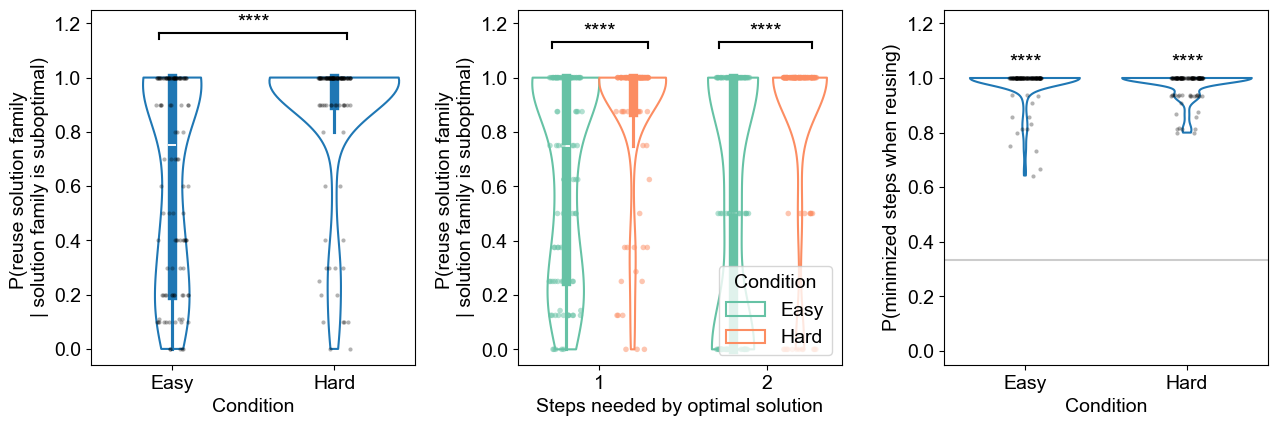

In [13]:
# Set the default font family to sans-serif
plt.rcParams['font.family'] = 'sans-serif'
# Specify Arial as the preferred sans-serif font
plt.rcParams['font.sans-serif'] = ['Arial']
# Set the default font size to 12
plt.rcParams['font.size'] = 13

# Set sizes globally
plt.rcParams.update({
    'axes.labelsize': 14,   # X and Y axis labels
    'xtick.labelsize': 14,  # X axis tick numbers
    'ytick.labelsize': 14,  # Y axis tick numbers
    'font.size': 14         # Default text size fallback
})

cut=0
inner="box"
num_experiments = len(experiment_names) + 1
palette = "Set2"
point_size = 4

df_temp = df_allsubjs_test_summary.copy()
df_temp["always_use_cached_solution_path"] = (df_temp["use_cached_solution_path"]==1).astype(int)

# Only analyze State Groups 2-3, where the cached solution is Einstellung
df_temp2 = df_allsubjs_test_summary_byeinstellung[df_allsubjs_test_summary_byeinstellung["is_einstellung_trial"]==1]
df_temp2["always_use_cached_solution_path"] = (df_temp2["use_cached_solution_path"]==1).astype(int)
print(df_temp2.groupby(["exp_cond"],as_index=False)["always_use_cached_solution_path"].mean())
print(df_temp2.groupby(["exp_cond"],as_index=True)["always_use_cached_solution_path"].std(ddof=1)/np.sqrt(110))

# Additionally stratigy by state group 2 vs 3.
df_temp3 = df_allsubjs_test_summary_bystategroup.copy()
df_temp3[df_temp3["state_group"]==1]["n_trials"] = 6
df_temp3[df_temp3["state_group"]!=1]["n_trials"] = 5


fig, ax = plt.subplots(1, 3, figsize=(13, 13/2.9))
g=sns.violinplot(data=df_temp2, y="use_cached_solution_path", x="exp_cond", fill=False, inner=inner, cut=cut, ax=ax[0], color="C0")
sns.stripplot(data=df_temp2, y="use_cached_solution_path", x="exp_cond", alpha=0.3, size=3, ax=ax[0], dodge=True, color="k", legend=False)
for exp_cond_easy in ["exp2color_0", "exp2visualsearch_0"]:
    annotate_ind_violin_significance(
        ax=ax[0],
        df=df_temp2,
        x="exp_cond",
        y="use_cached_solution_path",
        hue=None,
        comparisons=[ ((exp_cond_easy, None), ("exp2visualsearch_1", None)) ],  # <-- choose your x levels here
        paired=False,
        y_offset=0.15,
        cap_height=0.02,
        font_size=15,
        show="stars", #"stars" or "p"
    )
print()
ax[0].set_ylim([None,1.25])
ax[0].set_xlim([-0.5,1.5])
ax[0].set_xlabel("Condition")
ax[0].set_xticklabels(["Easy","Hard"])
ax[0].set_ylabel("P(reuse solution family \n| solution family is suboptimal)")



# Col 1

# Drop State Group 1 (where default sol family is optimal) for visualization.
df_temp4 = df_temp3.copy()
mapping = {'exp2color_0': 'Easy', 'exp2visualsearch_1': 'Hard'}
# Values not in mapping (like 'C') become NaN
df_temp4['Condition'] = df_temp4['exp_cond'].map(mapping)
df_temp4 = df_temp4[df_temp4['state_group'] !=1]
df_temp4['state_group'] = df_temp4['state_group'].astype(int)


# Another way of grouping: by the length of the optimal solution
df_temp5 = df_allsubjs_testtrials.copy()
df_temp5 = df_temp5[df_temp5["is_testtrial"]==1]
df_temp5 = df_temp5[df_temp5["state_group"]>=2]
df_temp5["optimal_sol_len"] = (df_temp5["state_group"] - df_temp5["solution_len_diff"]).astype(int)
df_temp51 = df_temp5.groupby(["subj_global","exp_cond","optimal_sol_len"], as_index=False)[["use_cached_solution_path"]].mean()
df_temp51['Condition'] = df_temp51['exp_cond'].map(mapping)

g=sns.violinplot(data=df_temp51, x="optimal_sol_len", y="use_cached_solution_path", hue="Condition", fill=False, inner=inner, cut=cut, ax=ax[1], palette=palette,  legend=True)
sns.stripplot(data=df_temp51, x="optimal_sol_len", y="use_cached_solution_path", hue="Condition", alpha=0.5, size=point_size, ax=ax[1], legend=False, dodge=True, jitter=0.2, palette=palette)
ax[1].set_xlabel("Steps needed by optimal solution")
ax[1].set_ylabel("P(reuse solution family \n| solution family is suboptimal)")
print("\n-----By optimal_path_len results--------")
print(df_temp51.groupby(["Condition","optimal_sol_len"], as_index=False)[["use_cached_solution_path"]].mean())
print(df_temp51.groupby(["Condition","optimal_sol_len"], as_index=False)[["use_cached_solution_path"]].sem(ddof=1))
print()


annotate_ind_violin_significance(
    ax=ax[1],
    df=df_temp51,
    x="optimal_sol_len",
    y="use_cached_solution_path",
    hue="exp_cond",
    comparisons=("exp2color_0", "exp2visualsearch_1"),
    paired=False,
    test="t",
    y_offset=0.12,
    cap_height=0.02,
    font_size=15,
    debug=False,
    show="stars", #"stars" or "p"
)
sns.move_legend(ax[1], "lower right")
ax[1].set_ylim([None,1.25])

# Col 2

df_allsubjs_testtrials_usedefault = df_allsubjs_testtrials[df_allsubjs_testtrials["use_cached_solution_path"]==1][["subj_global","exp_cond","condition","state_group","trial_idx","state_idx","num_submitted_eqs"]].copy()
# In State Group 1, one trial (state_idx=3) requires 2 steps if reuse cached solution
df_allsubjs_testtrials_usedefault["n_steps_needed_cached"] = df_allsubjs_testtrials_usedefault["state_group"]
mask2 = (
    (df_allsubjs_testtrials_usedefault["n_steps_needed_cached"] == 1) &
    (df_allsubjs_testtrials_usedefault["state_idx"] == 3)
)
df_allsubjs_testtrials_usedefault.loc[mask2, "n_steps_needed_cached"] = 2
#df_allsubjs_testtrials_usedefault = df_allsubjs_testtrials_usedefault[df_allsubjs_testtrials_usedefault["exp_cond"]=="exp2visualsearch_1"] # Only visualize hard condition; can remove
df_allsubjs_testtrials_usedefault["default_sensitivity"] = (df_allsubjs_testtrials_usedefault["n_steps_needed_cached"]==df_allsubjs_testtrials_usedefault["num_submitted_eqs"]).astype(int)

df_subjmean_testtrials_usedefault = df_allsubjs_testtrials_usedefault.groupby(["subj_global","exp_cond","condition"], as_index=False)["default_sensitivity"].mean()
sns.violinplot(data=df_subjmean_testtrials_usedefault, x="exp_cond",y="default_sensitivity", cut=cut, inner=inner, fill=False, ax=ax[2])
sns.stripplot(data=df_subjmean_testtrials_usedefault, x="exp_cond",y="default_sensitivity", dodge=True,
              color="k", alpha=0.3, size=3, legend=False, ax=ax[2])
annotate_violin_significance(
    ax=ax[2],
    df=df_subjmean_testtrials_usedefault,
    x="exp_cond",
    y="default_sensitivity",
    hue=None,
    test="t",            # "t" for one-sample t-test, "wilcoxon" for signed-rank
    mu=1/3,
    y_offset=0.02,
    min_height_pad=-0.1,
    font_size=15,
    show="stars",
)
ax[2].plot([-1,2],[1/3,1/3],"k-",alpha=0.2)
ax[2].set_xlim([-0.5,1.5])
ax[2].set_ylim([-0.05,1.25])
#ax[2].set_yticks([-0,0.5,1])
ax[2].set_ylabel("P(minimized steps when reusing)")
ax[2].set_xlabel("Condition")
ax[2].set_xticklabels(["Easy","Hard"])

fig.tight_layout()
# plt.savefig(os.path.join(figpath, "exp2_results"), dpi=300)
plt.savefig(os.path.join(figpath, "exp2_results.pdf"), bbox_inches='tight')
plt.show()

# Printing more statistical tests

In [14]:

equal_var = False


# 1) Test trial accuracy
print("1) Test trial accuracy (submitting a valid solution)")
print("\n-------------All test trials (State Groups 1-3)-------------")
print(df_temp.groupby(["exp_cond"])["is_correct"].mean())
print(df_temp.groupby(["exp_cond"])["is_correct"].median())
print(scipy.stats.ttest_ind(df_temp[df_temp["exp_cond"]=="exp2color_0"][["is_correct"]], df_temp[df_temp["exp_cond"]=="exp2visualsearch_1"][["is_correct"]], equal_var=equal_var))
print(scipy.stats.mannwhitneyu(df_temp[df_temp["exp_cond"]=="exp2color_0"][["is_correct"]], df_temp[df_temp["exp_cond"]=="exp2visualsearch_1"][["is_correct"]],))

print("\n-------------When the cached sol. family is suboptimal (State Groups 2-3)-------------")
print(df_temp2.groupby(["exp_cond"])["is_correct"].mean())
print(df_temp2.groupby(["exp_cond"])["is_correct"].median())
print(scipy.stats.ttest_ind(df_temp2[df_temp2["exp_cond"]=="exp2color_0"][["is_correct"]], df_temp2[df_temp2["exp_cond"]=="exp2visualsearch_1"][["is_correct"]], equal_var=equal_var))
print(scipy.stats.mannwhitneyu(df_temp2[df_temp2["exp_cond"]=="exp2color_0"][["is_correct"]], df_temp2[df_temp2["exp_cond"]=="exp2visualsearch_1"][["is_correct"]],))


# 2) # submitted equations
print("\n\n2) Number of submitted equations")
print("\n-------------All test trials (State Groups 1-3)-------------")
print(df_temp.groupby(["exp_cond"])["num_submitted_eqs"].mean())
print(df_temp.groupby(["exp_cond"])["num_submitted_eqs"].median())
print(scipy.stats.ttest_ind(df_temp[df_temp["exp_cond"]=="exp2color_0"][["num_submitted_eqs"]], df_temp[df_temp["exp_cond"]=="exp2visualsearch_1"][["num_submitted_eqs"]], equal_var=equal_var))
print(scipy.stats.mannwhitneyu(df_temp[df_temp["exp_cond"]=="exp2color_0"][["num_submitted_eqs"]], df_temp[df_temp["exp_cond"]=="exp2visualsearch_1"][["num_submitted_eqs"]],))

print("\n-------------When the cached sol. family is suboptimal (State Groups 2-3)-------------")
print(df_temp2.groupby(["exp_cond"])["num_submitted_eqs"].mean())
print(df_temp2.groupby(["exp_cond"])["num_submitted_eqs"].median())
print(scipy.stats.ttest_ind(df_temp2[df_temp2["exp_cond"]=="exp2color_0"][["num_submitted_eqs"]], df_temp2[df_temp2["exp_cond"]=="exp2visualsearch_1"][["num_submitted_eqs"]], equal_var=equal_var))
print(scipy.stats.mannwhitneyu(df_temp2[df_temp2["exp_cond"]=="exp2color_0"][["num_submitted_eqs"]], df_temp2[df_temp2["exp_cond"]=="exp2visualsearch_1"][["num_submitted_eqs"]],))


# 3) Pr(solution contains equations not in cheat sheet)
print("\n\n3) Pr(solution contains equations not in cheat sheet)")
print("\n-------------All test trials (State Groups 1-3)-------------")
print(df_temp.groupby(["exp_cond"])["contains_invalid_equations"].mean())
print(df_temp.groupby(["exp_cond"])["contains_invalid_equations"].median())
print(scipy.stats.ttest_ind(df_temp[df_temp["exp_cond"]=="exp2color_0"][["contains_invalid_equations"]], df_temp[df_temp["exp_cond"]=="exp2visualsearch_1"][["contains_invalid_equations"]], equal_var=equal_var))
print(scipy.stats.mannwhitneyu(df_temp[df_temp["exp_cond"]=="exp2color_0"][["contains_invalid_equations"]], df_temp[df_temp["exp_cond"]=="exp2visualsearch_1"][["contains_invalid_equations"]],))

print("\n-------------When the cached sol. family is suboptimal (State Groups 2-3)-------------")
print(df_temp2.groupby(["exp_cond"])["num_invalid_equations"].mean())
print(df_temp2.groupby(["exp_cond"])["num_invalid_equations"].median())
print(scipy.stats.ttest_ind(df_temp2[df_temp2["exp_cond"]=="exp2color_0"][["contains_invalid_equations"]], df_temp2[df_temp2["exp_cond"]=="exp2visualsearch_1"][["contains_invalid_equations"]], equal_var=equal_var))
print(scipy.stats.mannwhitneyu(df_temp2[df_temp2["exp_cond"]=="exp2color_0"][["contains_invalid_equations"]], df_temp2[df_temp2["exp_cond"]=="exp2visualsearch_1"][["contains_invalid_equations"]],))


# 4) Solution involves ingredients not initially available or produced earlier
print("\n\n4) Pr(solution involves ingredients not initially available or produced earlier)")
print("\n-------------All test trials (State Groups 1-3)-------------")
print(df_temp.groupby(["exp_cond"])["num_missing_produced_ints"].mean())
print(df_temp.groupby(["exp_cond"])["num_missing_produced_ints"].median())
print(scipy.stats.ttest_ind(df_temp[df_temp["exp_cond"]=="exp2color_0"][["num_missing_produced_ints"]], df_temp[df_temp["exp_cond"]=="exp2visualsearch_1"][["num_missing_produced_ints"]], equal_var=equal_var))
print(scipy.stats.mannwhitneyu(df_temp[df_temp["exp_cond"]=="exp2color_0"][["num_missing_produced_ints"]], df_temp[df_temp["exp_cond"]=="exp2visualsearch_1"][["num_missing_produced_ints"]],))

print("\n-------------When the cached sol. family is suboptimal (State Groups 2-3)-------------")
print(df_temp2.groupby(["exp_cond"])["num_missing_produced_ints"].mean())
print(df_temp2.groupby(["exp_cond"])["num_missing_produced_ints"].median())
print(scipy.stats.ttest_ind(df_temp2[df_temp2["exp_cond"]=="exp2color_0"][["num_missing_produced_ints"]], df_temp2[df_temp2["exp_cond"]=="exp2visualsearch_1"][["num_missing_produced_ints"]], equal_var=equal_var))
print(scipy.stats.mannwhitneyu(df_temp2[df_temp2["exp_cond"]=="exp2color_0"][["num_missing_produced_ints"]], df_temp2[df_temp2["exp_cond"]=="exp2visualsearch_1"][["num_missing_produced_ints"]],))


# 5) %participants always using default solution family
print("\n\n5) %participants always using default solution family")
print("\n-------------All test trials (State Groups 1-3)-------------")
print(df_temp.groupby(["exp_cond"],as_index=False)["always_use_cached_solution_path"].mean())
print(df_temp.groupby(["exp_cond"],as_index=True)["always_use_cached_solution_path"].std(ddof=1).to_numpy()/np.sqrt(n_subjs_bycond))
prop_subjects_alwaysreuse = df_temp.groupby(["exp_cond"],as_index=True)["always_use_cached_solution_path"].mean().to_numpy()
print(proportions_ztest(count=prop_subjects_alwaysreuse*n_subjs_bycond, 
                                               nobs=n_subjs_bycond, alternative='two-sided')
)

print("\n-------------When the cached sol. family is suboptimal (State Groups 2-3)-------------")
print(df_temp2.groupby(["exp_cond"],as_index=False)["always_use_cached_solution_path"].mean())
print(df_temp2.groupby(["exp_cond"],as_index=True)["always_use_cached_solution_path"].std(ddof=1).to_numpy()/np.sqrt(n_subjs_bycond))
prop_subjects_alwaysreuse = df_temp2.groupby(["exp_cond"],as_index=True)["always_use_cached_solution_path"].mean().to_numpy()
n_subjs_bycond = df_allsubjs_test_summary[["exp_cond"]].value_counts().to_numpy()
print(proportions_ztest(count=prop_subjects_alwaysreuse*n_subjs_bycond, 
                                               nobs=n_subjs_bycond, alternative='two-sided')
)

# 6) E[Pr(use default solution family)]
print("\n\n6) E[Pr(use default solution family)]")
print("\n-------------All test trials (State Groups 1-3)-------------")
print(df_temp.groupby(["exp_cond"])["use_cached_solution_path"].mean())
print(df_temp.groupby(["exp_cond"])["use_cached_solution_path"].median())
print(scipy.stats.ttest_ind(df_temp[df_temp["exp_cond"]=="exp2color_0"][["use_cached_solution_path"]], df_temp[df_temp["exp_cond"]=="exp2visualsearch_1"][["use_cached_solution_path"]], equal_var=equal_var))
print(scipy.stats.mannwhitneyu(df_temp[df_temp["exp_cond"]=="exp2color_0"][["use_cached_solution_path"]], df_temp[df_temp["exp_cond"]=="exp2visualsearch_1"][["use_cached_solution_path"]],))

print("\n-------------When the cached sol. family is suboptimal (State Groups 2-3)-------------")
print(df_temp2.groupby(["exp_cond"])["use_cached_solution_path"].mean())
print(df_temp2.groupby(["exp_cond"])["use_cached_solution_path"].median())
print(scipy.stats.ttest_ind(df_temp2[df_temp2["exp_cond"]=="exp2color_0"][["use_cached_solution_path"]], df_temp2[df_temp2["exp_cond"]=="exp2visualsearch_1"][["use_cached_solution_path"]], equal_var=equal_var))
print(scipy.stats.mannwhitneyu(df_temp2[df_temp2["exp_cond"]=="exp2color_0"][["use_cached_solution_path"]], df_temp2[df_temp2["exp_cond"]=="exp2visualsearch_1"][["use_cached_solution_path"]],))

1) Test trial accuracy (submitting a valid solution)

-------------All test trials (State Groups 1-3)-------------
exp_cond
exp2color_0           0.976629
exp2visualsearch_1    0.976935
Name: is_correct, dtype: float64
exp_cond
exp2color_0           1.0
exp2visualsearch_1    1.0
Name: is_correct, dtype: float64
TtestResult(statistic=array([-0.04867826]), pvalue=array([0.96122029]), df=array([217.90431433]))
MannwhitneyuResult(statistic=array([6022.]), pvalue=array([0.9394658]))

-------------When the cached sol. family is suboptimal (State Groups 2-3)-------------
exp_cond
exp2color_0           0.970909
exp2visualsearch_1    0.969773
Name: is_correct, dtype: float64
exp_cond
exp2color_0           1.0
exp2visualsearch_1    1.0
Name: is_correct, dtype: float64
TtestResult(statistic=array([0.12820204]), pvalue=array([0.89810831]), df=array([216.1051493]))
MannwhitneyuResult(statistic=array([6019.]), pvalue=array([0.92793306]))


2) Number of submitted equations

-------------All test tria

In [15]:
# Statistical tests: P(use cached solution family) differs across conditions?
equal_var=False
# 1) Across all test trials
print("\n-------------Across all test trials (State Groups 1-3)-------------")
print(df_temp.groupby(["exp_cond"])["use_cached_solution_path"].mean())
print(df_temp.groupby(["exp_cond"])["use_cached_solution_path"].median())
print(scipy.stats.ttest_ind(df_temp[df_temp["exp_cond"]=="exp2color_0"][["use_cached_solution_path"]], df_temp[df_temp["exp_cond"]=="exp2visualsearch_1"][["use_cached_solution_path"]], equal_var=equal_var))
print(scipy.stats.mannwhitneyu(df_temp[df_temp["exp_cond"]=="exp2color_0"][["use_cached_solution_path"]], df_temp[df_temp["exp_cond"]=="exp2visualsearch_1"][["use_cached_solution_path"]],))

# 2) For trials where the cached solution family is suboptimal (more steps; State Group 2-3)
print("\n-------------When the cached sol. family is suboptimal (State Groups 2-3)-------------")
print(df_temp2.groupby(["exp_cond"])["use_cached_solution_path"].mean())
print(df_temp2.groupby(["exp_cond"])["use_cached_solution_path"].sem(ddof=1))
print(df_temp2.groupby(["exp_cond"])["use_cached_solution_path"].median())
# visualsearch_0 vs. _1: ttest_ind(equal_var = False) requires N=36 subjects per cond for alpha=0.5 and beta=0.8. mannwhitneyu() requires N=39.
print(scipy.stats.ttest_ind(df_temp2[df_temp2["exp_cond"]=="exp2color_0"][["use_cached_solution_path"]], df_temp2[df_temp2["exp_cond"]=="exp2visualsearch_1"][["use_cached_solution_path"]], equal_var=equal_var))
print(scipy.stats.mannwhitneyu(df_temp2[df_temp2["exp_cond"]=="exp2color_0"][["use_cached_solution_path"]], df_temp2[df_temp2["exp_cond"]=="exp2visualsearch_1"][["use_cached_solution_path"]],))
# 3) By state group
print("\n-------------For each state group-------------")
for state_group in range(1,4):
    if(state_group==1):
        continue;
    print("\nState Group "+str(state_group) + ":")
    print(df_temp3[df_temp3["state_group"]==state_group].groupby(["exp_cond"])["use_cached_solution_path"].mean())
    print(df_temp3[df_temp3["state_group"]==state_group].groupby(["exp_cond"])["use_cached_solution_path"].sem(ddof=1))
    print(df_temp3[df_temp3["state_group"]==state_group].groupby(["exp_cond"])["use_cached_solution_path"].median())
    print(scipy.stats.ttest_ind(df_temp3[(df_temp3["exp_cond"]=="exp2color_0") & (df_temp3["state_group"]==state_group)][["use_cached_solution_path"]], df_temp3[(df_temp3["exp_cond"]=="exp2visualsearch_1") & (df_temp3["state_group"]==state_group)][["use_cached_solution_path"]], equal_var=equal_var))
    print(scipy.stats.mannwhitneyu(df_temp3[(df_temp3["exp_cond"]=="exp2color_0") & (df_temp3["state_group"]==state_group)][["use_cached_solution_path"]], df_temp3[(df_temp3["exp_cond"]=="exp2visualsearch_1") & (df_temp3["state_group"]==state_group)][["use_cached_solution_path"]],))
    


-------------Across all test trials (State Groups 1-3)-------------
exp_cond
exp2color_0           0.743523
exp2visualsearch_1    0.904633
Name: use_cached_solution_path, dtype: float64
exp_cond
exp2color_0           0.8125
exp2visualsearch_1    1.0000
Name: use_cached_solution_path, dtype: float64
TtestResult(statistic=array([-5.1937323]), pvalue=array([5.0423973e-07]), df=array([200.71465584]))
MannwhitneyuResult(statistic=array([3851.5]), pvalue=array([5.33318013e-07]))

-------------When the cached sol. family is suboptimal (State Groups 2-3)-------------
exp_cond
exp2color_0           0.633030
exp2visualsearch_1    0.866818
Name: use_cached_solution_path, dtype: float64
exp_cond
exp2color_0           0.035637
exp2visualsearch_1    0.026408
Name: use_cached_solution_path, dtype: float64
exp_cond
exp2color_0           0.75
exp2visualsearch_1    1.00
Name: use_cached_solution_path, dtype: float64
TtestResult(statistic=array([-5.27086894]), pvalue=array([3.48875012e-07]), df=array([2

# Below is all solution-driven model fitting

### Save human data file for Numpyro modeling

In [16]:
def check_sol_affordability(row, cached_sol_eq_idxs=[0,2,6]):
    # Pull the state and equations from the current row
    state = row['state']
    equations = row['equations']
    
    if(cached_sol_eq_idxs==[6]):
        is_affordable = state[8] & state[9]
    elif(cached_sol_eq_idxs==[2,6]):
        is_affordable = state[3] & state[4] & state[8]
    elif(cached_sol_eq_idxs==[0,2,6]):
        is_affordable = state[0] & state[1] & state[4] & state[8]
    else:
        print("This function does not work for noncached solutions!")
        return None
            
    return is_affordable

In [17]:
df_allsubjs_test_seq = df_allsubjs_testtrials.sort_values(by=['subj_global', 'trial_idx']).copy()
df_allsubjs_test_seq.rename(columns={"subj_global":"Subj", "trial_idx":"trial","test_condition":"cond"}, inplace=True)

# In State Group 1, one trial has cached solution require 2 steps
df_allsubjs_test_seq["L_cached_min"] = df_allsubjs_test_seq["state_group"]
mask2 = (
    (df_allsubjs_test_seq["L_cached_min"] == 1) &
    (df_allsubjs_test_seq["state_idx"] == 3)
)
df_allsubjs_test_seq.loc[mask2, "L_cached_min"] = 2

# How many ingredients does using each cached solution require?
df_allsubjs_test_seq['N_cached_min'] = df_allsubjs_test_seq['L_cached_min']*2

# Compute optimal #steps needed for each trial.
df_allsubjs_test_seq["L_search"] = df_allsubjs_test_seq["L_cached_min"] - df_allsubjs_test_seq["solution_len_diff"]

# Verify each cached solution
df_allsubjs_test_seq['1stepsol_open'] = df_allsubjs_test_seq.apply(
    check_sol_affordability, 
    axis=1, 
    args=([6],) # Passing [8] to the cached_sol_eq_idxs argument
)
df_allsubjs_test_seq['2stepsol_open'] = df_allsubjs_test_seq.apply(
    check_sol_affordability, 
    axis=1, 
    args=([2,6],) # Passing [8] to the cached_sol_eq_idxs argument
)
df_allsubjs_test_seq['3stepsol_open'] = df_allsubjs_test_seq.apply(
    check_sol_affordability, 
    axis=1, 
    args=([0,2,6],) # Passing [8] to the cached_sol_eq_idxs argument
)
df_allsubjs_test_seq["any_cachedsol_open"] = df_allsubjs_test_seq['1stepsol_open'] | df_allsubjs_test_seq['2stepsol_open'] | df_allsubjs_test_seq['3stepsol_open']
model_behav_data_cols = ["Subj","equations","trial","cond","state_idx", "state", 'any_cachedsol_open', '1stepsol_open',
       '2stepsol_open', '3stepsol_open',"submitted_eqs_indices","num_submitted_eqs","use_cached_solution_path","L_search","L_cached_min","N_cached_min"]
df_human_modeling = df_allsubjs_test_seq[model_behav_data_cols].copy()

In [18]:


def prepare_numpyro_inputs_alchemy(
    df_alchemy,
    subj_col="Subj",
    cond_col="cond",
    trial_col="trial",
    l_search_col="L_search",
    l_cached_min_col="L_cached_min",
    n_cached_min_col="N_cached_min",
    used_cached_col="use_cached_solution_path",
    num_submitted_eqs_col="num_submitted_eqs",
    cached_open_cols=("1stepsol_open", "2stepsol_open", "3stepsol_open"),
    l_budget=8,
    sort_df=True,
    validate=True,
):
    """
    Prepare alchemy dataframe for NumPyro models, in a structure parallel to the
    colored-maze inputs.

    Parameters
    ----------
    df_alchemy : pd.DataFrame
        One row per (subject, trial).
    subj_col, cond_col, trial_col : str
        Column names for subject, condition, and trial.
    l_search_col : str
        Objective shortest-solution length on that trial.
    l_cached_min_col, n_cached_min_col : str
        Columns already in the dataframe.
    used_cached_col : str
        Binary indicator: 1 if submitted solution was one of the cached solutions, else 0.
    num_submitted_eqs_col : str
        Number of equations submitted. When a cached solution is used, this is also
        the cached-solution label: 1, 2, or 3.
    cached_open_cols : tuple[str, str, str]
        Binary columns indicating whether the 1-step, 2-step, and 3-step cached
        solutions are available on that trial.
    l_budget : float
        Same role as in the maze models; used to compute EU_search = l_budget - L_search.
    sort_df : bool
        If True, sort by subject and trial before constructing arrays.
    validate : bool
        If True, run sanity checks.

    Returns
    -------
    inputs : dict
        Dictionary of numpy arrays suitable for downstream model code.
    df_sorted : pd.DataFrame
        Sorted dataframe aligned row-wise to the returned arrays.
    """
    df = df_alchemy.copy()

    # ------------------------------------------------------------------
    # Sort rows to create a stable trial order for NumPyro / PPC utilities
    # ------------------------------------------------------------------
    if sort_df:
        df = df.sort_values([subj_col, trial_col]).reset_index(drop=True)

    # ------------------------------------------------------------------
    # Build contiguous subject index: 0,1,2,... with no gaps
    # ------------------------------------------------------------------
    unique_subj = np.sort(df[subj_col].unique())
    subj_mapping = {s: i for i, s in enumerate(unique_subj)}
    df["subj_idx"] = df[subj_col].map(subj_mapping).astype(int)

    # ------------------------------------------------------------------
    # Condition index
    # ------------------------------------------------------------------
    df["cond_idx"] = df[cond_col].astype(int)

    # ------------------------------------------------------------------
    # Availability of the three cached solutions
    # cache_valid[t, :] = [1-step open, 2-step open, 3-step open]
    # ------------------------------------------------------------------
    cache_valid = np.stack(
        [df[c].astype(int).to_numpy() for c in cached_open_cols],
        axis=1
    )

    # ------------------------------------------------------------------
    # Choice label coding:
    #   0 = searched for non-cached / optimal solution outside cached set
    #   1 = reused 1-step cached solution
    #   2 = reused 2-step cached solution
    #   3 = reused 3-step cached solution
    #
    # As requested:
    #   obs_solution_slot = use_cached_solution_path * num_submitted_eqs
    # ------------------------------------------------------------------
    used_cached = df[used_cached_col].astype(int).to_numpy()
    num_submitted_eqs = df[num_submitted_eqs_col].astype(int).to_numpy()

    obs_solution_slot = used_cached * num_submitted_eqs

    # ------------------------------------------------------------------
    # Cached-solution "lengths" analogous to rim_path_length in maze models
    # Each trial has the three cached options with lengths 1, 2, 3.
    # ------------------------------------------------------------------
    rim_path_length = np.tile(np.array([1.0, 2.0, 3.0], dtype=float), (len(df), 1))

    # Number of represented ingredients for each cached solution:
    # N = 2 * L
    cache_N = 2.0 * rim_path_length

    # ------------------------------------------------------------------
    # Search-side quantities
    # ------------------------------------------------------------------
    L_search = df[l_search_col].astype(float).to_numpy()

    # This matches the same "reward-like" convention as before:
    # higher is better, shorter search solution gives larger utility.
    EU_search = l_budget - L_search

    # Search inspection burden is not provided yet and many of your current
    # models replace it with subject-level latent estimates anyway.
    EN_search = np.full(len(df), np.nan, dtype=float)

    # Per your request: placeholders for unused fields
    search_cost = np.full(len(df), np.nan, dtype=float)
    search_found = np.full(len(df), np.nan, dtype=float)

    # Additional columns for later models / debugging
    L_cached_min = df[l_cached_min_col].astype(float).to_numpy()
    N_cached_min = df[n_cached_min_col].astype(float).to_numpy()

    # ------------------------------------------------------------------
    # Validation
    # ------------------------------------------------------------------
    if validate:
        # obs_solution_slot should be 0,1,2,3
        bad_obs = ~np.isin(obs_solution_slot, [0, 1, 2, 3])
        if np.any(bad_obs):
            bad_rows = np.where(bad_obs)[0][:10]
            raise ValueError(
                f"obs_solution_slot contains values outside {{0,1,2,3}} at rows {bad_rows.tolist()}."
            )

        # If cached solution used, num_submitted_eqs should be 1,2,3
        bad_cached = (used_cached == 1) & (~np.isin(num_submitted_eqs, [1, 2, 3]))
        if np.any(bad_cached):
            bad_rows = np.where(bad_cached)[0][:10]
            raise ValueError(
                f"Rows where cached solution was used but num_submitted_eqs is not in {{1,2,3}}: "
                f"{bad_rows.tolist()}"
            )

        # cache_valid should be binary
        if not np.all(np.isin(cache_valid, [0, 1])):
            raise ValueError("cache_valid contains values other than 0/1.")

        # L_search should be positive
        if np.any(~np.isfinite(L_search)) or np.any(L_search <= 0):
            raise ValueError("L_search contains non-finite or non-positive values.")

        # One condition per subject, per your task design
        conds_per_subj = df.groupby("subj_idx")["cond_idx"].nunique()
        if np.any(conds_per_subj > 1):
            bad_subj = conds_per_subj[conds_per_subj > 1].index.tolist()
            raise ValueError(
                f"Some subjects appear in more than one condition: subj_idx={bad_subj}"
            )

    inputs = {
        "subj_idx": df["subj_idx"].to_numpy(dtype=int),
        "cond_idx": df["cond_idx"].to_numpy(dtype=int),

        # Core choice-model arrays
        "cache_valid": cache_valid,                  # shape [T, 3]
        "rim_path_length": rim_path_length,          # shape [T, 3]
        "cache_N": cache_N,                          # shape [T, 3]
        "obs_solution_slot": obs_solution_slot.astype(int),  # shape [T]

        # Search-side arrays
        "EU_search": EU_search.astype(float),        # shape [T]
        "EN_search": EN_search,                      # shape [T], nan placeholder
        "L_search": L_search.astype(float),          # shape [T]

        # Placeholders / auxiliary
        "search_cost": search_cost,                  # shape [T], nan placeholder
        "search_found": search_found,                # shape [T], nan placeholder
        "L_cached_min": L_cached_min.astype(float),  # shape [T]
        "N_cached_min": N_cached_min.astype(float),  # shape [T]

        "metadata": {
            "task": "alchemy",
            "sort_by": (subj_col, trial_col),
            "original_subj_col": subj_col,
            "original_cond_col": cond_col,
            "original_trial_col": trial_col,
            "subj_mapping": subj_mapping,
            "cached_open_cols": cached_open_cols,
            "choice_labels": {
                0: "search_noncached",
                1: "reuse_1step",
                2: "reuse_2step",
                3: "reuse_3step",
            },
        },
    }

    return inputs, df


inputs, df_sorted = prepare_numpyro_inputs_alchemy(df_human_modeling)
df_sorted["obs_solution_slot"] = list(inputs["obs_solution_slot"])
df_sorted["cache_valid"] = list(inputs["cache_valid"])
df_sorted["cached_sol_length"] = list(inputs["rim_path_length"])

## Numpyro fits

In [19]:
import numpyro
numpyro.set_host_device_count(4) 
import numpyro.distributions as dist
import jax
import jax.numpy as jnp

def _take_subj(theta_subj, subj_idx):
    """
    theta_subj shape: [..., S]
    subj_idx shape: [T]
    returns: [..., T]
    """
    return jnp.take(theta_subj, subj_idx, axis=-1)


def _take_subj_k(theta_subj_k, subj_idx):
    """
    theta_subj_k shape: [..., S, K]
    subj_idx shape: [T]
    returns: [..., T, K]
    """
    return jnp.take(theta_subj_k, subj_idx, axis=-2)


def _take_subj_cond(theta_subj_cond, subj_idx, cond_idx):
    """
    theta_subj_cond shape: [..., S, C]
    subj_idx shape: [T]
    cond_idx shape: [T]
    returns: [..., T]
    """
    # First index subjects -> [..., T, C]
    tmp = jnp.take(theta_subj_cond, subj_idx, axis=-2)

    # Then select condition at each trial
    # Build an index tensor with the right number of leading singleton dims.
    idx = cond_idx
    expand_shape = (1,) * (tmp.ndim - 2) + idx.shape + (1,)
    idx = jnp.reshape(idx, expand_shape)

    return jnp.take_along_axis(tmp, idx, axis=-1)[..., 0]


def utility_hierarchical(
    subj_idx,              # shape [T], integer-coded 0..S-1
    cond_idx,              # shape [T], integer-coded 0..C-1
    cache_valid,           # shape [T, K], 1 if cached option is available/open
    rim_path_length,       # shape [T, K], utility-relevant "length" of each cached option
    EU_search,             # kept for API compatibility; unused in this version
    EN_search,             # kept for API compatibility; unused in this version
    obs_solution_slot=None,# shape [T], 0=search, 1..K = reuse cached option
    n_subj=None,
    n_cond=None,
    L_budget=8,
):
    """
    Generalized hierarchical static softmax model.

    Supports any number K of cached options:
        0   = search
        1..K = cached reuse options

    Works for:
        - colored mazes: K=2
        - alchemy:       K=3

    Notes:
        EU_search and EN_search are accepted for compatibility with your
        existing pipeline but are not used in this model version.
    """
    if n_subj is None:
        raise ValueError("n_subj must be provided as a Python int.")
    if n_cond is None:
        raise ValueError("n_cond must be provided as a Python int.")

    T = subj_idx.shape[0]

    if cache_valid.shape != rim_path_length.shape:
        raise ValueError("cache_valid and rim_path_length must have the same shape [T, K].")

    if cache_valid.ndim != 2:
        raise ValueError("cache_valid must have shape [T, K].")

    K = cache_valid.shape[1]
    if K < 1:
        raise ValueError("Need at least one cached option (K >= 1).")

    # -----------------------------
    # Subject-level inverse temperature beta_s > 0
    # -----------------------------
    mu_log_beta = numpyro.sample("mu_log_beta", dist.Normal(-1.0, 0.5))
    sigma_log_beta = numpyro.sample("sigma_log_beta", dist.HalfNormal(0.4))
    z_beta = numpyro.sample("z_beta", dist.Normal(0.0, 1.0).expand([n_subj]))
    log_beta_subj = mu_log_beta[..., None] + sigma_log_beta[..., None] * z_beta
    beta_subj = numpyro.deterministic("beta_subj", jnp.exp(log_beta_subj))   # [..., S]

    # -----------------------------
    # Subject-level blocked/unavailable-option aversion kappa_s > 0
    # -----------------------------
    mu_log_kappa = numpyro.sample("mu_log_kappa", dist.Normal(2.5, 0.5))
    sigma_log_kappa = numpyro.sample("sigma_log_kappa", dist.HalfNormal(0.4))
    z_kappa = numpyro.sample("z_kappa", dist.Normal(0.0, 1.0).expand([n_subj]))
    log_kappa_subj = mu_log_kappa[..., None] + sigma_log_kappa[..., None] * z_kappa
    kappa_subj = numpyro.deterministic("kappa_subj", jnp.exp(log_kappa_subj))  # [..., S]

    # -----------------------------
    # Subject-level cached-option biases rho_{s,k}
    # One rho per subject per cached option
    # -----------------------------
    mu_rho = numpyro.sample(
        "mu_rho",
        dist.Normal(jnp.zeros(K), 10.0).to_event(1)
    )
    sigma_rho = numpyro.sample(
        "sigma_rho",
        dist.HalfNormal(jnp.ones(K) * 5.0).to_event(1)
    )
    z_rho = numpyro.sample("z_rho", dist.Normal(0.0, 1.0).expand([n_subj, K]))
    rho_subj = numpyro.deterministic(
        "rho_subj",
        mu_rho[..., None, :] + sigma_rho[..., None, :] * z_rho
    )  # [..., S, K]

    # -----------------------------
    # Subjective search burden N_search_s > 0
    # -----------------------------
    mu_log_Nsearch = numpyro.sample("mu_log_Nsearch", dist.Normal(jnp.log(20.0), 0.5))
    sigma_log_Nsearch = numpyro.sample("sigma_log_Nsearch", dist.HalfNormal(0.4))
    z_Nsearch = numpyro.sample("z_Nsearch", dist.Normal(0.0, 1.0).expand([n_subj]))
    log_Nsearch_subj = mu_log_Nsearch[..., None] + sigma_log_Nsearch[..., None] * z_Nsearch
    N_search_subj = numpyro.deterministic("N_search_subj", jnp.exp(log_Nsearch_subj))  # [..., S]

    # -----------------------------
    # Subjective expected length of search solution L_search_s > 0
    # -----------------------------
    mu_log_Lsearch = numpyro.sample("mu_log_Lsearch", dist.Normal(jnp.log(20.0), 0.4))
    sigma_log_Lsearch = numpyro.sample("sigma_log_Lsearch", dist.HalfNormal(0.3))
    z_Lsearch = numpyro.sample("z_Lsearch", dist.Normal(0.0, 1.0).expand([n_subj]))
    log_Lsearch_subj = mu_log_Lsearch[..., None] + sigma_log_Lsearch[..., None] * z_Lsearch
    L_search_subj = numpyro.deterministic("L_search_subj", jnp.exp(log_Lsearch_subj))  # [..., S]

    # -----------------------------
    # Subject x condition lambda_{s,c} > 0
    # Generalized to arbitrary number of conditions
    # -----------------------------
    mu_log_lambda_cond = numpyro.sample(
        "mu_log_lambda_cond",
        dist.Normal(jnp.zeros(n_cond), 0.5).to_event(1)
    )
    sigma_log_lambda_cond = numpyro.sample(
        "sigma_log_lambda_cond",
        dist.HalfNormal(jnp.ones(n_cond) * 0.3).to_event(1)
    )
    z_lambda = numpyro.sample("z_lambda", dist.Normal(0.0, 1.0).expand([n_subj, n_cond]))
    log_lambda_subj_cond = (
        mu_log_lambda_cond[..., None, :] +
        sigma_log_lambda_cond[..., None, :] * z_lambda
    )
    lambda_subj_cond = numpyro.deterministic(
        "lambda_subj_cond",
        jnp.exp(log_lambda_subj_cond)
    )  # [..., S, C]

    # -----------------------------
    # Trial-level indexing
    # -----------------------------
    beta_t = _take_subj(beta_subj, subj_idx)                    # [..., T]
    kappa_t = _take_subj(kappa_subj, subj_idx)                  # [..., T]
    rho_t = _take_subj_k(rho_subj, subj_idx)                    # [..., T, K]
    N_search_t = _take_subj(N_search_subj, subj_idx)            # [..., T]
    L_search_t = _take_subj(L_search_subj, subj_idx)            # [..., T]
    lambda_t = _take_subj_cond(lambda_subj_cond, subj_idx, cond_idx)  # [..., T]

    # -----------------------------
    # Cached-option utilities
    #
    # If available:  L_budget - rim_path_length
    # If unavailable: -kappa_t
    # Then add subject-option-specific rho
    # -----------------------------
    U_cache_base = jnp.where(
        cache_valid == 1,
        L_budget - rim_path_length,
        -kappa_t[..., None]
    )  # [..., T, K] after broadcasting

    U_cache = U_cache_base + rho_t  # [..., T, K]

    # -----------------------------
    # Search utility
    # -----------------------------
    U_search = (L_budget - L_search_t) - lambda_t * N_search_t  # [..., T]

    # Combine search + cached options
    utilities = jnp.concatenate([U_search[..., None], U_cache], axis=-1)  # [..., T, K+1]
    logits = beta_t[..., None] * utilities

    numpyro.deterministic("utilities", utilities)
    numpyro.deterministic("logits", logits)
    numpyro.deterministic("obs_probs", jax.nn.softmax(logits, axis=-1))

    with numpyro.plate("trials", T):
        numpyro.sample("obs", dist.Categorical(logits=logits), obs=obs_solution_slot)

In [20]:
def utility_hierarchical_null(
    subj_idx,              # shape [T], integer-coded 0..S-1
    cond_idx,              # shape [T], integer-coded 0..C-1 (kept for API compatibility; unused)
    cache_valid,           # shape [T, K], 1 if cached option is available/open
    rim_path_length,       # shape [T, K], utility-relevant "length" of each cached option
    EU_search,             # kept for API compatibility; unused in this version
    EN_search,             # kept for API compatibility; unused in this version
    obs_solution_slot=None,# shape [T], 0=search, 1..K = reuse cached option
    n_subj=None,
    n_cond=None,           # kept for API compatibility; unused in this version
    L_budget=8,
):
    """
    Null hierarchical static softmax model.

    Relative to the fuller model, this null version removes condition-specific
    lambda differences. Each subject has one shared lambda_subj > 0 that applies
    to all conditions.

    Supports any number K of cached options:
        0   = search
        1..K = cached reuse options

    Works for:
        - colored mazes: K=2
        - alchemy:       K=3

    Notes:
        EU_search, EN_search, cond_idx, and n_cond are accepted for compatibility
        with the existing pipeline but are not used to vary lambda here.
    """
    if n_subj is None:
        raise ValueError("n_subj must be provided as a Python int.")
    if n_cond is None:
        raise ValueError("n_cond must be provided as a Python int.")

    T = subj_idx.shape[0]

    if cache_valid.shape != rim_path_length.shape:
        raise ValueError("cache_valid and rim_path_length must have the same shape [T, K].")

    if cache_valid.ndim != 2:
        raise ValueError("cache_valid must have shape [T, K].")

    K = cache_valid.shape[1]
    if K < 1:
        raise ValueError("Need at least one cached option (K >= 1).")

    # -----------------------------
    # Subject-level inverse temperature beta_s > 0
    # -----------------------------
    mu_log_beta = numpyro.sample("mu_log_beta", dist.Normal(-1.0, 0.5))
    sigma_log_beta = numpyro.sample("sigma_log_beta", dist.HalfNormal(0.4))
    z_beta = numpyro.sample("z_beta", dist.Normal(0.0, 1.0).expand([n_subj]))
    log_beta_subj = mu_log_beta[..., None] + sigma_log_beta[..., None] * z_beta
    beta_subj = numpyro.deterministic("beta_subj", jnp.exp(log_beta_subj))   # [..., S]

    # -----------------------------
    # Subject-level blocked/unavailable-option aversion kappa_s > 0
    # -----------------------------
    mu_log_kappa = numpyro.sample("mu_log_kappa", dist.Normal(2.5, 0.5))
    sigma_log_kappa = numpyro.sample("sigma_log_kappa", dist.HalfNormal(0.4))
    z_kappa = numpyro.sample("z_kappa", dist.Normal(0.0, 1.0).expand([n_subj]))
    log_kappa_subj = mu_log_kappa[..., None] + sigma_log_kappa[..., None] * z_kappa
    kappa_subj = numpyro.deterministic("kappa_subj", jnp.exp(log_kappa_subj))  # [..., S]

    # -----------------------------
    # Subject-level cached-option biases rho_{s,k}
    # One rho per subject per cached option
    # -----------------------------
    mu_rho = numpyro.sample(
        "mu_rho",
        dist.Normal(jnp.zeros(K), 10.0).to_event(1)
    )
    sigma_rho = numpyro.sample(
        "sigma_rho",
        dist.HalfNormal(jnp.ones(K) * 5.0).to_event(1)
    )
    z_rho = numpyro.sample("z_rho", dist.Normal(0.0, 1.0).expand([n_subj, K]))
    rho_subj = numpyro.deterministic(
        "rho_subj",
        mu_rho[..., None, :] + sigma_rho[..., None, :] * z_rho
    )  # [..., S, K]

    # -----------------------------
    # Subjective search burden N_search_s > 0
    # -----------------------------
    mu_log_Nsearch = numpyro.sample("mu_log_Nsearch", dist.Normal(jnp.log(20.0), 0.5))
    sigma_log_Nsearch = numpyro.sample("sigma_log_Nsearch", dist.HalfNormal(0.4))
    z_Nsearch = numpyro.sample("z_Nsearch", dist.Normal(0.0, 1.0).expand([n_subj]))
    log_Nsearch_subj = mu_log_Nsearch[..., None] + sigma_log_Nsearch[..., None] * z_Nsearch
    N_search_subj = numpyro.deterministic("N_search_subj", jnp.exp(log_Nsearch_subj))  # [..., S]

    # -----------------------------
    # Subjective expected length of search solution L_search_s > 0
    # -----------------------------
    mu_log_Lsearch = numpyro.sample("mu_log_Lsearch", dist.Normal(jnp.log(20.0), 0.4))
    sigma_log_Lsearch = numpyro.sample("sigma_log_Lsearch", dist.HalfNormal(0.3))
    z_Lsearch = numpyro.sample("z_Lsearch", dist.Normal(0.0, 1.0).expand([n_subj]))
    log_Lsearch_subj = mu_log_Lsearch[..., None] + sigma_log_Lsearch[..., None] * z_Lsearch
    L_search_subj = numpyro.deterministic("L_search_subj", jnp.exp(log_Lsearch_subj))  # [..., S]

    # -----------------------------
    # Null model: one lambda_s > 0 per subject, shared across conditions
    # -----------------------------
    mu_log_lambda = numpyro.sample("mu_log_lambda", dist.Normal(0.0, 0.5))
    sigma_log_lambda = numpyro.sample("sigma_log_lambda", dist.HalfNormal(0.3))
    z_lambda = numpyro.sample("z_lambda", dist.Normal(0.0, 1.0).expand([n_subj]))
    log_lambda_subj = mu_log_lambda[..., None] + sigma_log_lambda[..., None] * z_lambda
    lambda_subj = numpyro.deterministic("lambda_subj", jnp.exp(log_lambda_subj))  # [..., S]

    # -----------------------------
    # Trial-level indexing
    # -----------------------------
    beta_t = _take_subj(beta_subj, subj_idx)         # [..., T]
    kappa_t = _take_subj(kappa_subj, subj_idx)       # [..., T]
    rho_t = _take_subj_k(rho_subj, subj_idx)         # [..., T, K]
    N_search_t = _take_subj(N_search_subj, subj_idx) # [..., T]
    L_search_t = _take_subj(L_search_subj, subj_idx) # [..., T]
    lambda_t = _take_subj(lambda_subj, subj_idx)     # [..., T]

    # -----------------------------
    # Cached-option utilities
    #
    # If available:  L_budget - rim_path_length
    # If unavailable: -kappa_t
    # Then add subject-option-specific rho
    # -----------------------------
    U_cache_base = jnp.where(
        cache_valid == 1,
        L_budget - rim_path_length,
        -kappa_t[..., None]
    )  # [..., T, K] after broadcasting

    U_cache = U_cache_base + rho_t  # [..., T, K]

    # -----------------------------
    # Search utility
    # -----------------------------
    U_search = (L_budget - L_search_t) - lambda_t * N_search_t  # [..., T]

    # Combine search + cached options
    utilities = jnp.concatenate([U_search[..., None], U_cache], axis=-1)  # [..., T, K+1]
    logits = beta_t[..., None] * utilities

    numpyro.deterministic("utilities", utilities)
    numpyro.deterministic("logits", logits)
    numpyro.deterministic("obs_probs", jax.nn.softmax(logits, axis=-1))

    with numpyro.plate("trials", T):
        numpyro.sample("obs", dist.Categorical(logits=logits), obs=obs_solution_slot)

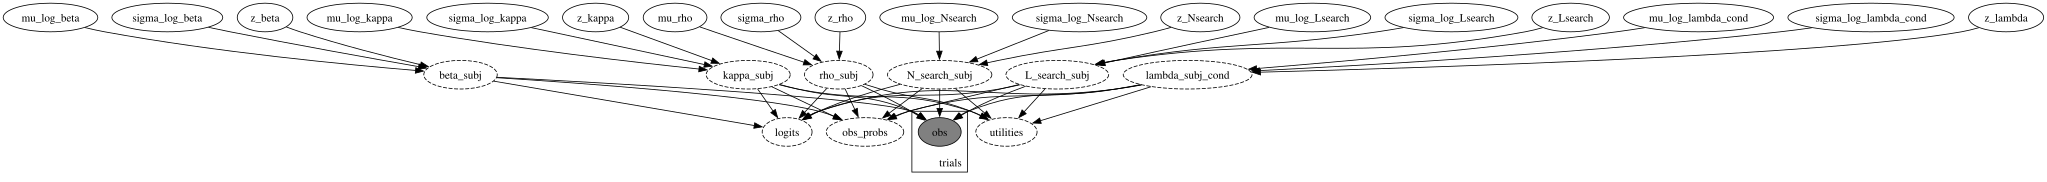

In [21]:

n_subj = int(np.max(inputs["subj_idx"])) + 1
n_cond = int(np.max(inputs["cond_idx"])) + 1
numpyro.render_model(utility_hierarchical, model_args=(    
    jnp.array(inputs["subj_idx"]),
    jnp.array(inputs["cond_idx"]),
    jnp.array(inputs["cache_valid"]),
    jnp.array(inputs["rim_path_length"]),
    jnp.array(inputs["EU_search"]),
    jnp.array(inputs["EN_search"]),
    jnp.array(inputs["obs_solution_slot"]),
    n_subj,
    n_cond,),
    filename=os.path.join(figpath,'exp2_model.png'))

In [22]:
# numpyro.set_host_device_count(4)

# Example of setting the count (optional, often done at the start of a script)
# numpyro.set_host_device_count(4) 

# Check the configured number of devices JAX is set to use per host
# This value reflects the setting from set_host_device_count()
configured_device_count = jax.local_device_count()
print(f"Configured number of devices for parallelism: {configured_device_count}")



Configured number of devices for parallelism: 4


In [23]:
import os
import pickle
import numpy as np
import pandas as pd

import jax
import jax.numpy as jnp
import numpyro
from numpyro.infer import NUTS, MCMC


# ============================================================
# Metrics
# ============================================================

def categorical_log_loss(y, p, eps=1e-15):
    """
    Mean negative log probability assigned to observed class.

    y: shape [T], integer labels 0..C-1
    p: shape [T, C], predicted probabilities
    """
    y = np.asarray(y, dtype=int)
    p = np.clip(np.asarray(p), eps, 1.0 - eps)
    return -np.mean(np.log(p[np.arange(len(y)), y]))


def multiclass_brier_score(y, p):
    """
    Mean multiclass Brier score:
        mean_t sum_c (p_tc - 1[y_t=c])^2
    """
    y = np.asarray(y, dtype=int)
    p = np.asarray(p)
    y_onehot = np.eye(p.shape[1])[y]
    return np.mean(np.sum((p - y_onehot) ** 2, axis=1))


def multiclass_accuracy(y, p):
    y = np.asarray(y, dtype=int)
    pred = np.argmax(p, axis=1)
    return np.mean(pred == y)


def binary_log_loss(y, p, eps=1e-15):
    y = np.asarray(y, dtype=int)
    p = np.clip(np.asarray(p), eps, 1.0 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))


def binary_brier_score(y, p):
    y = np.asarray(y, dtype=int)
    p = np.asarray(p)
    return np.mean((p - y) ** 2)


def binary_accuracy(y, p):
    y = np.asarray(y, dtype=int)
    return np.mean((p >= 0.5) == y)


# ============================================================
# Subject-grouped stratified folds
# ============================================================

def make_stratified_group_folds(y_binary, group, K=5, seed=0):
    """
    Holds out entire participants while greedily balancing binary response rate.

    For Experiment 2, use:
        y_binary = (obs_solution_slot != 0).astype(int)

    This mirrors your R make_stratified_folds().
    """
    rng = np.random.default_rng(seed)

    y_binary = np.asarray(y_binary, dtype=int)
    group = np.asarray(group).astype(str)

    if not np.all(np.isin(y_binary, [0, 1])):
        raise ValueError("y_binary must contain only 0/1 values.")

    group_levels = pd.unique(group)

    if len(group_levels) < K:
        raise ValueError(
            f"Number of groups ({len(group_levels)}) is smaller than K ({K})."
        )

    rows = []
    for g in group_levels:
        idx = np.where(group == g)[0]
        n = len(idx)
        n_pos = int(y_binary[idx].sum())
        rows.append({
            "group": g,
            "n": n,
            "n_pos": n_pos,
            "prop_pos": n_pos / n,
        })

    group_summary = pd.DataFrame(rows)

    # Randomize ties, then sort high-to-low by reuse rate.
    group_summary = (
        group_summary
        .sample(frac=1.0, random_state=seed)
        .sort_values("prop_pos", ascending=False)
        .reset_index(drop=True)
    )

    folds_groups = [[] for _ in range(K)]
    fold_n = np.zeros(K, dtype=float)
    fold_pos = np.zeros(K, dtype=float)

    global_prop = y_binary.mean()

    for _, row in group_summary.iterrows():
        this_n = row["n"]
        this_pos = row["n_pos"]

        candidate_scores = []
        for k in range(K):
            new_n = fold_n[k] + this_n
            new_pos = fold_pos[k] + this_pos
            new_prop = new_pos / new_n

            score = abs(new_prop - global_prop) + 0.001 * new_n
            candidate_scores.append(score)

        k_best = int(np.argmin(candidate_scores))

        folds_groups[k_best].append(row["group"])
        fold_n[k_best] += this_n
        fold_pos[k_best] += this_pos

    folds = []
    for gs in folds_groups:
        test_idx = np.where(np.isin(group, gs))[0]
        folds.append(test_idx)

    return folds

def predict_probs_population_only_alchemy(
    posterior_samples,
    cond_idx,
    cache_valid,
    rim_path_length,
    L_budget=8,
):
    """
    Population-level prediction for held-out Experiment 2 subjects.

    Works for both:
      - utility_hierarchical, with condition-specific mu_log_lambda_cond
      - utility_hierarchical_null, with shared mu_log_lambda

    Held-out subject-level z terms are set to zero.
    """
    cond_idx = jnp.asarray(cond_idx)
    cache_valid = jnp.asarray(cache_valid)
    rim_path_length = jnp.asarray(rim_path_length)

    T, K = cache_valid.shape

    # -----------------------------
    # Population-level parameters, z = 0
    # -----------------------------
    beta = jnp.exp(posterior_samples["mu_log_beta"])          # [D]
    kappa = jnp.exp(posterior_samples["mu_log_kappa"])        # [D]

    rho = posterior_samples["mu_rho"]                         # [D, K]

    N_search = jnp.exp(posterior_samples["mu_log_Nsearch"])   # [D]
    L_search = jnp.exp(posterior_samples["mu_log_Lsearch"])   # [D]

    # Full model: condition-specific lambda.
    if "mu_log_lambda_cond" in posterior_samples:
        mu_log_lambda_cond = posterior_samples["mu_log_lambda_cond"]  # [D, C]
        lambda_t = jnp.exp(mu_log_lambda_cond[:, cond_idx])           # [D, T]

    # Null model: one shared lambda.
    elif "mu_log_lambda" in posterior_samples:
        lambda_t = jnp.exp(posterior_samples["mu_log_lambda"])[:, None]  # [D, 1]
        lambda_t = jnp.broadcast_to(lambda_t, (beta.shape[0], T))        # [D, T]

    else:
        raise KeyError(
            "Posterior must contain either 'mu_log_lambda_cond' or 'mu_log_lambda'."
        )

    # Broadcast to [D, T] or [D, T, K]
    beta_t = beta[:, None]                         # [D, T via broadcast]
    kappa_t = kappa[:, None]                       # [D, T via broadcast]
    N_search_t = N_search[:, None]
    L_search_t = L_search[:, None]

    cache_valid_b = cache_valid[None, :, :]        # [1, T, K]
    rim_length_b = rim_path_length[None, :, :]     # [1, T, K]

    # -----------------------------
    # Cached option utilities
    # -----------------------------
    U_cache_base = jnp.where(
        cache_valid_b == 1,
        L_budget - rim_length_b,
        -kappa_t[:, :, None],
    )                                               # [D, T, K]

    U_cache = U_cache_base + rho[:, None, :]        # [D, T, K]

    # -----------------------------
    # Search utility
    # -----------------------------
    U_search = (L_budget - L_search_t) - lambda_t * N_search_t  # [D, T]

    utilities = jnp.concatenate(
        [U_search[:, :, None], U_cache],
        axis=-1,
    )                                               # [D, T, K+1]

    logits = beta_t[:, :, None] * utilities         # [D, T, K+1]

    probs = jax.nn.softmax(logits, axis=-1)         # [D, T, K+1]
    p_mean = probs.mean(axis=0)                     # [T, K+1]

    return np.asarray(p_mean)


def fit_one_numpyro_model_alchemy(
    model,
    inputs,
    n_subj,
    n_cond,
    seed=0,
    num_warmup=4000,
    num_samples=2000,
    num_chains=4,
    target_accept_prob=0.8,
    L_budget=8,
):
    kernel = NUTS(model, target_accept_prob=target_accept_prob)

    mcmc = MCMC(
        kernel,
        num_warmup=num_warmup,
        num_samples=num_samples,
        num_chains=num_chains,
    )

    mcmc.run(
        jax.random.PRNGKey(seed),
        subj_idx=jnp.array(inputs["subj_idx"]),
        cond_idx=jnp.array(inputs["cond_idx"]),
        cache_valid=jnp.array(inputs["cache_valid"]),
        rim_path_length=jnp.array(inputs["rim_path_length"]),
        EU_search=jnp.array(inputs["EU_search"]),
        EN_search=jnp.array(inputs["EN_search"]),
        obs_solution_slot=jnp.array(inputs["obs_solution_slot"]),
        n_subj=int(n_subj),
        n_cond=int(n_cond),
        L_budget=L_budget,
    )

    return mcmc

def cv_numpyro_alchemy_by_subject(
    df_alchemy,
    model,
    K=5,
    seed=0,
    L_budget=8,
    num_warmup=4000,
    num_samples=2000,
    num_chains=4,
    target_accept_prob=0.8,
    fit_full=True,

    # Passed into prepare_numpyro_inputs_alchemy
    subj_col="Subj",
    cond_col="cond",
    trial_col="trial",
    l_search_col="L_search",
    l_cached_min_col="L_cached_min",
    n_cached_min_col="N_cached_min",
    used_cached_col="use_cached_solution_path",
    num_submitted_eqs_col="num_submitted_eqs",
    cached_open_cols=("1stepsol_open", "2stepsol_open", "3stepsol_open"),
):
    """
    5-fold between-participant grouped CV for Experiment 2 Alchemy models.

    Works for:
      - utility_hierarchical
      - utility_hierarchical_null

    Main CV metric:
      - mean_logloss: 4-choice categorical log loss

    Secondary metric:
      - reuse_logloss: binary search-vs-cached log loss
    """

    # ------------------------------------------------------------
    # Prepare full sorted dataframe once, only to define stable rows/folds
    # ------------------------------------------------------------
    full_inputs, df_sorted_full = prepare_numpyro_inputs_alchemy(
        df_alchemy,
        subj_col=subj_col,
        cond_col=cond_col,
        trial_col=trial_col,
        l_search_col=l_search_col,
        l_cached_min_col=l_cached_min_col,
        n_cached_min_col=n_cached_min_col,
        used_cached_col=used_cached_col,
        num_submitted_eqs_col=num_submitted_eqs_col,
        cached_open_cols=cached_open_cols,
        l_budget=L_budget,
        sort_df=True,
        validate=True,
    )

    # Binary stratification target: search vs cached reuse.
    y_reuse_binary = (full_inputs["obs_solution_slot"] != 0).astype(int)

    folds = make_stratified_group_folds(
        y_binary=y_reuse_binary,
        group=df_sorted_full[subj_col].to_numpy(),
        K=K,
        seed=seed,
    )

    n_cond_full = int(np.max(full_inputs["cond_idx"])) + 1

    rows = []
    fold_results = []

    for fold_id, te_idx in enumerate(folds, start=1):
        tr_idx = np.setdiff1d(np.arange(len(df_sorted_full)), te_idx)

        train_df_raw = df_sorted_full.iloc[tr_idx].copy()
        test_df_raw = df_sorted_full.iloc[te_idx].copy()

        # Re-prepare inputs separately so training subjects are reindexed 0..S_train-1.
        train_inputs, train_df = prepare_numpyro_inputs_alchemy(
            train_df_raw,
            subj_col=subj_col,
            cond_col=cond_col,
            trial_col=trial_col,
            l_search_col=l_search_col,
            l_cached_min_col=l_cached_min_col,
            n_cached_min_col=n_cached_min_col,
            used_cached_col=used_cached_col,
            num_submitted_eqs_col=num_submitted_eqs_col,
            cached_open_cols=cached_open_cols,
            l_budget=L_budget,
            sort_df=True,
            validate=True,
        )

        # Test inputs can also be prepared normally.
        # Its subject indices are irrelevant for prediction because held-out
        # subjects use population-level predictions only.
        test_inputs, test_df = prepare_numpyro_inputs_alchemy(
            test_df_raw,
            subj_col=subj_col,
            cond_col=cond_col,
            trial_col=trial_col,
            l_search_col=l_search_col,
            l_cached_min_col=l_cached_min_col,
            n_cached_min_col=n_cached_min_col,
            used_cached_col=used_cached_col,
            num_submitted_eqs_col=num_submitted_eqs_col,
            cached_open_cols=cached_open_cols,
            l_budget=L_budget,
            sort_df=True,
            validate=True,
        )

        n_train_subj = int(np.max(train_inputs["subj_idx"])) + 1

        mcmc_k = fit_one_numpyro_model_alchemy(
            model=model,
            inputs=train_inputs,
            n_subj=n_train_subj,
            n_cond=n_cond_full,
            seed=seed + fold_id,
            num_warmup=num_warmup,
            num_samples=num_samples,
            num_chains=num_chains,
            target_accept_prob=target_accept_prob,
            L_budget=L_budget,
        )

        posterior_k = mcmc_k.get_samples()

        p_test = predict_probs_population_only_alchemy(
            posterior_samples=posterior_k,
            cond_idx=test_inputs["cond_idx"],
            cache_valid=test_inputs["cache_valid"],
            rim_path_length=test_inputs["rim_path_length"],
            L_budget=L_budget,
        )

        y_test = test_inputs["obs_solution_slot"]

        # ------------------------------------------------------------
        # Four-choice metrics: search / reuse-1 / reuse-2 / reuse-3
        # ------------------------------------------------------------
        mean_logloss = categorical_log_loss(y_test, p_test)
        brier = multiclass_brier_score(y_test, p_test)
        acc = multiclass_accuracy(y_test, p_test)

        # ------------------------------------------------------------
        # Binary search-vs-reuse metrics
        # ------------------------------------------------------------
        y_reuse_test = (y_test != 0).astype(int)
        p_reuse_test = p_test[:, 1:].sum(axis=1)

        reuse_logloss = binary_log_loss(y_reuse_test, p_reuse_test)
        reuse_brier = binary_brier_score(y_reuse_test, p_reuse_test)
        reuse_acc = binary_accuracy(y_reuse_test, p_reuse_test)

        rows.append(dict(
            fold=fold_id,
            n_train=len(train_df),
            n_test=len(test_df),
            n_train_subjects=train_df[subj_col].nunique(),
            n_test_subjects=test_df[subj_col].nunique(),
            n_with_RE=0,
            n_FE_only=len(test_df),

            mean_logloss=mean_logloss,
            brier=brier,
            acc=acc,

            reuse_logloss=reuse_logloss,
            reuse_brier=reuse_brier,
            reuse_acc=reuse_acc,
        ))

        fold_results.append(dict(
            fold=fold_id,
            mcmc=mcmc_k,
            posterior_samples=posterior_k,
            train_index=tr_idx,
            test_index=te_idx,
            train_df=train_df,
            test_df=test_df,
            p_test=p_test,
            y_test=y_test,
        ))

    cv_table = pd.DataFrame(rows)

    cv_avg = cv_table[
        [
            "mean_logloss",
            "brier",
            "acc",
            "reuse_logloss",
            "reuse_brier",
            "reuse_acc",
        ]
    ].mean()

    out = dict(
        cv_table=cv_table,
        cv_avg=cv_avg,
        fold_results=fold_results, # Too large to save
        cv_type="Experiment 2 between-participant grouped 5-fold CV; held-out predictions use population-level parameters only",
    )

    # ------------------------------------------------------------
    # Optional full-data fit for posterior summaries / PPCs
    # ------------------------------------------------------------
    if fit_full:
        n_subj_full = int(np.max(full_inputs["subj_idx"])) + 1

        mcmc_full = fit_one_numpyro_model_alchemy(
            model=model,
            inputs=full_inputs,
            n_subj=n_subj_full,
            n_cond=n_cond_full,
            seed=seed,
            num_warmup=num_warmup,
            num_samples=num_samples,
            num_chains=num_chains,
            target_accept_prob=target_accept_prob,
            L_budget=L_budget,
        )

        out["fit_full"] = mcmc_full
        out["posterior_full"] = mcmc_full.get_samples()
        out["full_inputs"] = full_inputs
        out["df_sorted_full"] = df_sorted_full

    return out

In [30]:
cv_res = cv_numpyro_alchemy_by_subject(
    df_alchemy=df_human_modeling,
    model=utility_hierarchical_null,
    K=5,
    seed=0,
    L_budget=8,
    num_warmup=4000,
    num_samples=2000,
    num_chains=4,
    target_accept_prob=0.8,
    fit_full=True,
)

print(cv_res["cv_table"])
print(cv_res["cv_avg"])

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

...

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

   fold  n_train  n_test  n_train_subjects  n_test_subjects  n_with_RE  \
0     1     2803     698               176               44          0   
1     2     2799     702               176               44          0   
2     3     2799     702               176               44          0   
3     4     2800     701               176               44          0   
4     5     2803     698               176               44          0   

   n_FE_only  mean_logloss     brier       acc  reuse_logloss  reuse_brier  \
0        698      0.708872  0.334009  0.812321       0.623070     0.157300   
1        702      0.768350  0.359599  0.799145       0.655723     0.161763   
2        702      0.743237  0.350161  0.804843       0.661876     0.163413   
3        701      0.749415  0.349041  0.807418       0.673657     0.162286   
4        698      0.820803  0.351594  0.803725       0.631110     0.156080   

   reuse_acc  
0   0.826648  
1   0.823362  
2   0.821937  
3   0.824536  
4   0.82808

In [31]:
# with open(os.path.join(fitspath,'exp2_sol_driven_model_hierarchical_null_5foldcv.pickle'), 'wb') as handle:
#     pickle.dump(cv_res, handle, protocol=pickle.HIGHEST_PROTOCOL)

# 5-fold CV model comparison

In [24]:
# Load fitted models

with open(os.path.join(fitspath, "exp2_sol_driven_model_hierarchical_5foldcv.pickle"), "rb") as handle:
    cv_target = pickle.load(handle)
    del cv_target["fold_results"] # Loading both files with all dict keys would overload RAM

with open(os.path.join(fitspath, "exp2_sol_driven_model_hierarchical_null_5foldcv.pickle"), "rb") as handle:
    cv_null = pickle.load(handle)
    del cv_null["fold_results"]

print("\n----- Target model -------")
print(cv_target["cv_avg"])

print("\n----- Null model -------")
print(cv_null["cv_avg"])



----- Target model -------
mean_logloss     0.689593
brier            0.323946
acc              0.805490
reuse_logloss    0.580916
reuse_brier      0.147806
reuse_acc        0.824913
dtype: float64

----- Null model -------
mean_logloss     0.758135
brier            0.348881
acc              0.805490
reuse_logloss    0.649087
reuse_brier      0.160168
reuse_acc        0.824913
dtype: float64


In [25]:
def get_exp2_full_fit_samples_and_inputs(
    cv_res,
    df_human_modeling=None,
    L_budget=8,
):
    """
    Extract posterior samples and full-data inputs from the new Experiment 2
    5-fold-CV result object.

    Expected keys from the newer CV code:
        cv_res["posterior_full"]
        cv_res["full_inputs"]

    If full_inputs is missing, reconstruct it from df_human_modeling.
    """
    if "posterior_full" in cv_res:
        posterior_samples = cv_res["posterior_full"]
    elif "fit_full" in cv_res:
        posterior_samples = cv_res["fit_full"].get_samples()
    else:
        raise KeyError(
            "Could not find posterior samples. Expected 'posterior_full' or 'fit_full'."
        )

    if "full_inputs" in cv_res:
        inputs = cv_res["full_inputs"]
    else:
        if df_human_modeling is None:
            raise KeyError(
                "cv_res does not contain 'full_inputs'. "
                "Pass df_human_modeling so inputs can be reconstructed."
            )

        inputs, _ = prepare_numpyro_inputs_alchemy(
            df_human_modeling,
            l_budget=L_budget,
            sort_df=True,
            validate=True,
        )

    return posterior_samples, inputs


def compute_loo_for_alchemy_model_from_cvres(
    cv_res,
    model_fn,
    df_human_modeling=None,
    L_budget=8,
):
    """
    Compute PSIS-LOO / ELPD-LOO for an Experiment 2 NumPyro model
    using the full-data fit stored inside a newer 5-fold-CV result object.

    Works for:
        utility_hierarchical
        utility_hierarchical_null
    """
    posterior_samples, inputs = get_exp2_full_fit_samples_and_inputs(
        cv_res,
        df_human_modeling=df_human_modeling,
        L_budget=L_budget,
    )

    posterior_samples_unchained = {
        k: np.asarray(v)
        for k, v in posterior_samples.items()
    }

    n_subj = int(np.max(inputs["subj_idx"])) + 1
    n_cond = int(np.max(inputs["cond_idx"])) + 1

    log_lik = log_likelihood(
        model_fn,
        posterior_samples_unchained,
        subj_idx=jnp.array(inputs["subj_idx"]),
        cond_idx=jnp.array(inputs["cond_idx"]),
        cache_valid=jnp.array(inputs["cache_valid"]),
        rim_path_length=jnp.array(inputs["rim_path_length"]),
        EU_search=jnp.array(inputs["EU_search"]),
        EN_search=jnp.array(inputs["EN_search"]),
        obs_solution_slot=jnp.array(inputs["obs_solution_slot"]),
        n_subj=n_subj,
        n_cond=n_cond,
        L_budget=L_budget,
    )

    # Add singleton chain dimension for ArviZ:
    # posterior:      (draws, ...) -> (1, draws, ...)
    # log_likelihood: (draws, T)   -> (1, draws, T)
    posterior_samples_chained = {
        k: np.expand_dims(v, axis=0)
        for k, v in posterior_samples_unchained.items()
    }

    log_lik_chained = {
        "obs": np.expand_dims(np.asarray(log_lik["obs"]), axis=0)
    }

    idata = az.from_dict(
        posterior=posterior_samples_chained,
        log_likelihood=log_lik_chained,
    )

    loo_res = az.loo(
        idata,
        var_name="obs",
        pointwise=True,
    )

    return loo_res, idata


loo_target, idata_target = compute_loo_for_alchemy_model_from_cvres(
    cv_target,
    utility_hierarchical,
    df_human_modeling=df_human_modeling,
    L_budget=8,
)

loo_null, idata_null = compute_loo_for_alchemy_model_from_cvres(
    cv_null,
    utility_hierarchical_null,
    df_human_modeling=df_human_modeling,
    L_budget=8,
)


cmp = az.compare(
    {
        "target_condition_specific_lambda": idata_target,
        "null_shared_lambda": idata_null,
    },
    ic="loo",
)

print(cmp)

print("\n----- Target model LOO -----")
print(loo_target)

print("\n----- Null model LOO -----")
print(loo_null)

/Users/liu_s/pyro_env2/lib/python3.11/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/liu_s/pyro_env2/lib/python3.11/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/liu_s/pyro_env2/lib/python3.11/site-packages/arviz/stat

                                  rank     elpd_loo       p_loo  elpd_diff  \
target_condition_specific_lambda     0 -1150.793198  252.176328   0.000000   
null_shared_lambda                   1 -1155.321076  257.046841   4.527878   

                                        weight         se       dse  warning  \
target_condition_specific_lambda  1.000000e+00  41.280917  0.000000     True   
null_shared_lambda                2.220446e-15  41.845977  2.287327     True   

                                 scale  
target_condition_specific_lambda   log  
null_shared_lambda                 log  

----- Target model LOO -----
Computed from 8000 posterior samples and 3501 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1150.79    41.28
p_loo      252.18        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     3445   98.4%
   (0.70, 1]   (ba

# Posterior predictive samples visualization

Note: these figures correspond to the participant-level 5-fold cross validation results. For each participant, we use the fitted model in which they belonged to the held-out fold (i.e., the model was deliberatedly NOT fit to this participant's data), and sample participant-level parameters from the fitted population-level prior distribution. We then used these parameters to generate the participant's data on each trial. 

The above procedure is thus a test of model generalization/predictions on held-out participants.

In [26]:
import gc
import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
from numpyro.infer import Predictive

In [33]:
# ============================================================
# Model Column 1:
# P(reuse solution family | family is suboptimal)
# ============================================================

def summarize_exp2_model_col1(df_pred):
    df_model_col1 = df_pred.copy()

    if "is_einstellung_trial" in df_model_col1.columns:
        df_model_col1 = df_model_col1[
            df_model_col1["is_einstellung_trial"] == 1
        ].copy()
    else:
        df_model_col1 = df_model_col1[
            df_model_col1["state_group"] >= 2
        ].copy()

    subj_col = "subj_global" if "subj_global" in df_model_col1.columns else "Subj"

    group_cols = ["row_type", subj_col, "exp_cond"]
    if "sim" in df_model_col1.columns:
        group_cols = ["row_type", "sim", subj_col, "exp_cond"]

    out = (
        df_model_col1
        .groupby(group_cols, as_index=False)
        .agg(plot_value=("p_reuse_any", "mean"))
    )

    return out


# ============================================================
# Model Column 2:
# P(reuse solution family | family is suboptimal), by optimal len
# ============================================================

def summarize_exp2_model_col2(df_pred):
    df_model_col2 = df_pred.copy()

    if "is_testtrial" in df_model_col2.columns:
        df_model_col2 = df_model_col2[df_model_col2["is_testtrial"] == 1].copy()

    df_model_col2 = df_model_col2[df_model_col2["state_group"] >= 2].copy()

    df_model_col2["optimal_sol_len"] = (
        df_model_col2["state_group"] - df_model_col2["solution_len_diff"]
    ).astype(int)

    subj_col = "subj_global" if "subj_global" in df_model_col2.columns else "Subj"

    group_cols = ["row_type", subj_col, "exp_cond", "optimal_sol_len"]
    if "sim" in df_model_col2.columns:
        group_cols = ["row_type", "sim", subj_col, "exp_cond", "optimal_sol_len"]

    out = (
        df_model_col2
        .groupby(group_cols, as_index=False)
        .agg(plot_value=("p_reuse_any", "mean"))
    )

    return out


# ============================================================
# Model Column 3:
# P(minimized steps when reusing)
# ============================================================

def summarize_exp2_model_col3(df_pred, eps=1e-12):
    df_model_col3 = df_pred.copy()

    pred_mode_vals = df_model_col3["pred_mode"].dropna().unique().tolist()
    if len(pred_mode_vals) != 1:
        raise ValueError(
            "Expected one pred_mode per dataframe. "
            f"Found: {pred_mode_vals}"
        )

    pred_mode = pred_mode_vals[0]

    if "is_testtrial" in df_model_col3.columns:
        df_model_col3 = df_model_col3[df_model_col3["is_testtrial"] == 1].copy()

    df_model_col3["n_steps_needed_cached"] = df_model_col3["state_group"]

    mask2_model = (
        (df_model_col3["n_steps_needed_cached"] == 1) &
        (df_model_col3["state_idx"] == 3)
    )

    df_model_col3.loc[mask2_model, "n_steps_needed_cached"] = 2

    subj_col = "subj_global" if "subj_global" in df_model_col3.columns else "Subj"

    group_cols = ["row_type", subj_col, "exp_cond"]
    if "condition" in df_model_col3.columns:
        group_cols.append("condition")
    if "sim" in df_model_col3.columns:
        group_cols = ["row_type", "sim", subj_col, "exp_cond"] + (
            ["condition"] if "condition" in df_model_col3.columns else []
        )

    if pred_mode == "probs":
        df_model_col3["p_correct_cached"] = np.nan

        df_model_col3.loc[
            df_model_col3["n_steps_needed_cached"] == 1,
            "p_correct_cached"
        ] = df_model_col3.loc[
            df_model_col3["n_steps_needed_cached"] == 1,
            "p_reuse_1step"
        ]

        df_model_col3.loc[
            df_model_col3["n_steps_needed_cached"] == 2,
            "p_correct_cached"
        ] = df_model_col3.loc[
            df_model_col3["n_steps_needed_cached"] == 2,
            "p_reuse_2step"
        ]

        df_model_col3.loc[
            df_model_col3["n_steps_needed_cached"] == 3,
            "p_correct_cached"
        ] = df_model_col3.loc[
            df_model_col3["n_steps_needed_cached"] == 3,
            "p_reuse_3step"
        ]

        df_model_col3["plot_value"] = (
            df_model_col3["p_correct_cached"] /
            np.clip(df_model_col3["p_reuse_any"], eps, None)
        )

    elif pred_mode == "choices":
        # Condition on sampled reuse, matching human filtering.
        df_model_col3 = df_model_col3[df_model_col3["y_pred"].isin([1, 2, 3])].copy()

        df_model_col3["plot_value"] = (
            df_model_col3["y_pred"] == df_model_col3["n_steps_needed_cached"]
        ).astype(float)

    else:
        raise ValueError("pred_mode must be 'probs' or 'choices'.")

    out = (
        df_model_col3
        .groupby(group_cols, as_index=False)
        .agg(plot_value=("plot_value", "mean"))
    )

    return out


def _get_fold_results(cv_res):
    if "fold_results" not in cv_res:
        raise KeyError(
            "cv_res does not contain 'fold_results'. "
            "Need fold-specific results for held-out CV PPC plots."
        )
    return cv_res["fold_results"]


def _get_fold_test_df(fr):
    for key in ["test_df", "df_test", "test_data"]:
        if key in fr:
            return fr[key].copy()
    raise KeyError(
        "Could not find held-out test dataframe in fold result. "
        "Expected one of: 'test_df', 'df_test', 'test_data'."
    )


def _get_fold_p_test(fr):
    for key in ["p_test", "probs_test", "pred_probs_test"]:
        if key in fr:
            return np.asarray(fr[key])
    raise KeyError(
        "Could not find held-out predicted probabilities in fold result. "
        "Expected one of: 'p_test', 'probs_test', 'pred_probs_test'."
    )


def _get_fold_posterior_samples(fr):
    for key in ["posterior_samples", "samples", "posterior"]:
        if key in fr:
            return fr[key]

    if "mcmc" in fr:
        return fr["mcmc"].get_samples()

    if "fit" in fr:
        return fr["fit"].get_samples()

    raise KeyError(
        "Could not find fold-specific posterior samples. "
        "Need fr['posterior_samples'] or fr['mcmc']/fr['fit'] for "
        "participant_mode='sampled_re'."
    )


def _coerce_probs_to_mean(probs):
    """
    Accept either:
        [T, 4]          posterior mean probabilities
        [draws, T, 4]   posterior draw-level probabilities

    Returns:
        [T, 4]
    """
    probs = np.asarray(probs)

    if probs.ndim == 2:
        return probs

    if probs.ndim == 3:
        return probs.mean(axis=0)

    raise ValueError(
        f"Expected p_test shape [T, 4] or [draws, T, 4], got {probs.shape}."
    )


def _sample_choices_from_probs(probs, rng):
    """
    Exp 2 action coding:
        0 = search / non-cached
        1 = reuse 1-step cached solution
        2 = reuse 2-step cached solution
        3 = reuse 3-step cached solution
    """
    probs = np.asarray(probs, dtype=float)
    probs = probs / probs.sum(axis=1, keepdims=True)

    return np.array([
        rng.choice(probs.shape[1], p=probs[t])
        for t in range(probs.shape[0])
    ])

In [34]:
def attach_exp2_metadata_to_fold_test_df(
    test_df,
    df_metadata,
    left_keys=("Subj", "trial"),
    right_keys=("subj_global", "trial_idx"),
):
    """
    Attach Experiment 2 metadata to a fold-specific held-out test dataframe.

    If metadata columns are already present, this returns test_df mostly unchanged.
    Otherwise it merges:
        test_df[Subj, trial] <-> df_metadata[subj_global, trial_idx]
    """
    test_df = test_df.copy()
    df_meta = df_metadata.copy()

    metadata_cols_wanted = [
        "subj_global",
        "exp_cond",
        "condition",
        "state_group",
        "solution_len_diff",
        "state_idx",
        "trial_idx",
        "is_testtrial",
        "is_einstellung_trial",
        "use_cached_solution_path",
        "num_submitted_eqs",
    ]

    missing_metadata = [
        c for c in metadata_cols_wanted
        if c not in test_df.columns and c in df_meta.columns
    ]

    if len(missing_metadata) == 0:
        return test_df

    missing_left = [c for c in left_keys if c not in test_df.columns]
    missing_right = [c for c in right_keys if c not in df_meta.columns]

    if missing_left or missing_right:
        raise KeyError(
            "Cannot attach metadata by merge.\n"
            f"Missing left keys in test_df: {missing_left}\n"
            f"Missing right keys in df_metadata: {missing_right}\n"
            "Either include metadata in fold test_df, or adjust left_keys/right_keys."
        )

    meta_keep = list(right_keys) + [
        c for c in metadata_cols_wanted
        if c in df_meta.columns and c not in right_keys
    ]

    df_meta_small = df_meta[meta_keep].drop_duplicates(list(right_keys)).copy()

    out = test_df.merge(
        df_meta_small,
        left_on=list(left_keys),
        right_on=list(right_keys),
        how="left",
        suffixes=("", "_meta"),
        validate="many_to_one",
    )

    for c in metadata_cols_wanted:
        c_meta = c + "_meta"
        if c not in out.columns and c_meta in out.columns:
            out[c] = out[c_meta]
        elif c in out.columns and c_meta in out.columns:
            out[c] = out[c].where(~out[c].isna(), out[c_meta])

    drop_cols = [c for c in out.columns if c.endswith("_meta")]
    out = out.drop(columns=drop_cols)

    return out

In [35]:
def _reindex_heldout_subjects_exp2(test_df, subj_col=None):
    """
    Reindex held-out subjects to 0..S_test-1 so the model samples new
    subject-level effects for the held-out participants.
    """
    test_df = test_df.copy()

    if subj_col is None:
        if "subj_idx" in test_df.columns:
            subj_col = "subj_idx"
        elif "Subj" in test_df.columns:
            subj_col = "Subj"
        elif "subj_global" in test_df.columns:
            subj_col = "subj_global"
        else:
            raise KeyError(
                "Could not find subject column. Expected 'subj_idx', 'Subj', or 'subj_global'."
            )

    unique_subjs = pd.unique(test_df[subj_col])
    subj_map = {s: i for i, s in enumerate(unique_subjs)}
    subj_idx_new = test_df[subj_col].map(subj_map).to_numpy(dtype=int)

    return subj_idx_new, subj_map


def _coerce_exp2_rim_path_length(rim_path_length, T):
    """
    Coerce Experiment 2 cached-solution lengths to shape [T, 3].

    Accepts:
        scalar       -> same length for all three cached families
        shape [3]    -> repeated over trials
        shape [T]    -> duplicated across three columns
        shape [T, 3] -> unchanged
        shape [1, 3] -> repeated over trials
    """
    rpl = np.asarray(rim_path_length, dtype=float)

    if rpl.ndim == 0:
        return float(rpl) * np.ones((T, 3))

    if rpl.ndim == 1:
        if rpl.shape[0] == 3:
            return np.tile(rpl[None, :], (T, 1))

        if rpl.shape[0] == T:
            return np.column_stack([rpl, rpl, rpl])

        raise ValueError(
            f"rim_path_length is 1D with shape {rpl.shape}; expected [3] or [T]."
        )

    if rpl.ndim == 2:
        if rpl.shape == (T, 3):
            return rpl

        if rpl.shape == (1, 3):
            return np.tile(rpl, (T, 1))

        if rpl.shape == (T, 1):
            return np.repeat(rpl, 3, axis=1)

        raise ValueError(
            f"rim_path_length has shape {rpl.shape}; expected [T, 3], [1, 3], or [T, 1]."
        )

    raise ValueError(f"rim_path_length has unsupported shape {rpl.shape}.")


def _build_exp2_test_inputs_from_test_df(
    test_df,
    L_budget=8,
    rim_path_length=None,
    EU_search=None,
    EN_search=None,
):
    """
    Build Experiment 2 model inputs for a held-out test dataframe.

    Required:
        subject column: subj_idx, Subj, or subj_global
        condition column: cond_idx or cond
        cache_valid, or columns 1stepsol_open/2stepsol_open/3stepsol_open

    For alchemy:
        rim_path_length usually = np.array([1.0, 2.0, 3.0])
    """
    test_df = test_df.reset_index(drop=True).copy()
    T = len(test_df)

    subj_idx_new, subj_map = _reindex_heldout_subjects_exp2(test_df)

    if "cond_idx" in test_df.columns:
        cond_idx = test_df["cond_idx"].to_numpy(dtype=int)
    elif "cond" in test_df.columns:
        cond_idx = test_df["cond"].to_numpy(dtype=int)
    elif "exp_cond" in test_df.columns:
        exp_cond_order = ["exp2color_0", "exp2visualsearch_1"]
        cond_map = {c: i for i, c in enumerate(exp_cond_order)}
        cond_idx = test_df["exp_cond"].map(cond_map).to_numpy(dtype=int)
    else:
        raise KeyError("test_df needs 'cond_idx', 'cond', or 'exp_cond'.")

    if "cache_valid" in test_df.columns:
        cache_valid = np.stack(test_df["cache_valid"].to_numpy()).astype(float)
    elif all(c in test_df.columns for c in ["1stepsol_open", "2stepsol_open", "3stepsol_open"]):
        cache_valid = test_df[
            ["1stepsol_open", "2stepsol_open", "3stepsol_open"]
        ].to_numpy(dtype=float)
    else:
        raise KeyError(
            "test_df needs 'cache_valid' or columns "
            "'1stepsol_open', '2stepsol_open', '3stepsol_open'."
        )

    if cache_valid.shape != (T, 3):
        raise ValueError(
            f"cache_valid has shape {cache_valid.shape}; expected {(T, 3)}."
        )

    if "rim_path_length" in test_df.columns:
        try:
            rpl = np.stack(test_df["rim_path_length"].to_numpy()).astype(float)
        except Exception:
            rpl = test_df["rim_path_length"].to_numpy(dtype=float)
        rpl = _coerce_exp2_rim_path_length(rpl, T)
    else:
        if rim_path_length is None:
            rim_path_length = np.array([1.0, 2.0, 3.0])
        rpl = _coerce_exp2_rim_path_length(rim_path_length, T)

    if "EU_search" in test_df.columns:
        eu = test_df["EU_search"].to_numpy(dtype=float)
    else:
        if EU_search is None:
            raise ValueError(
                "EU_search not found in test_df. Pass EU_search explicitly."
            )
        eu = np.asarray(EU_search, dtype=float)
        if eu.ndim == 0:
            eu = np.repeat(float(eu), T)
        elif eu.ndim == 1 and eu.shape[0] == T:
            pass
        else:
            raise ValueError(
                f"EU_search has unexpected shape {eu.shape}; expected scalar or [T]."
            )

    if "EN_search" in test_df.columns:
        en = test_df["EN_search"].to_numpy(dtype=float)
    else:
        if EN_search is None:
            raise ValueError(
                "EN_search not found in test_df. Pass EN_search explicitly."
            )
        en = np.asarray(EN_search, dtype=float)
        if en.ndim == 0:
            en = np.repeat(float(en), T)
        elif en.ndim == 1 and en.shape[0] == T:
            pass
        else:
            raise ValueError(
                f"EN_search has unexpected shape {en.shape}; expected scalar or [T]."
            )

    inputs = dict(
        subj_idx=subj_idx_new,
        cond_idx=cond_idx,
        cache_valid=cache_valid,
        rim_path_length=rpl,
        EU_search=eu,
        EN_search=en,
        obs_solution_slot=None,
        n_subj=len(subj_map),
        n_cond=int(np.max(cond_idx)) + 1,
        L_budget=L_budget,
    )

    return inputs

In [36]:
def _drop_subject_level_sites_exp2(posterior_samples):
    """
    Keep population-level posterior samples, but drop subject-level latent sites
    so NumPyro samples new held-out-subject random effects.

    This is intentionally conservative.
    """
    drop_prefixes = (
        "z_",                  # non-centered subject-level latent sites
        "subj_",               # possible subject-specific deterministic names
        "log_beta_subj",
        "log_lambda_subj",
        "lambda_subj",
        "beta_subj",
    )

    drop_exact = {
        "obs_probs",
        "logits",
        "probs",
    }

    out = {}

    for k, v in posterior_samples.items():
        if k in drop_exact:
            continue

        if any(k.startswith(prefix) for prefix in drop_prefixes):
            continue

        out[k] = np.asarray(v)

    return out


def predict_exp2_heldout_probs_sampled_re(
    fr,
    model_fn,
    rng_key,
    L_budget=8,
    rim_path_length=None,
    EU_search=None,
    EN_search=None,
    max_draws=None,
):
    """
    Compute held-out predictive probabilities after sampling new held-out
    participant-level parameters from fold-specific posterior population-level
    distributions.

    This does NOT match fixed-effect-only grouped CV loss. It is an exploratory
    new-participant posterior predictive visualization.
    """
    test_df = _get_fold_test_df(fr).reset_index(drop=True)

    posterior_samples = _get_fold_posterior_samples(fr)

    if max_draws is not None:
        posterior_samples = {
            k: np.asarray(v)[:max_draws]
            for k, v in posterior_samples.items()
        }

    posterior_population = _drop_subject_level_sites_exp2(posterior_samples)

    if "test_inputs" in fr:
        inputs = fr["test_inputs"].copy()

        subj_idx_new, subj_map = _reindex_heldout_subjects_exp2(test_df)
        inputs["subj_idx"] = subj_idx_new
        inputs["n_subj"] = len(subj_map)
        inputs["obs_solution_slot"] = None

        if "cond_idx" not in inputs and "cond" in inputs:
            inputs["cond_idx"] = inputs["cond"]

        if "n_cond" not in inputs:
            inputs["n_cond"] = int(np.max(inputs["cond_idx"])) + 1

        if "rim_path_length" not in inputs:
            inputs["rim_path_length"] = _coerce_exp2_rim_path_length(
                rim_path_length if rim_path_length is not None else np.array([1.0, 2.0, 3.0]),
                len(test_df),
            )
        else:
            inputs["rim_path_length"] = _coerce_exp2_rim_path_length(
                inputs["rim_path_length"],
                len(test_df),
            )

        if "L_budget" not in inputs:
            inputs["L_budget"] = L_budget

    else:
        inputs = _build_exp2_test_inputs_from_test_df(
            test_df=test_df,
            L_budget=L_budget,
            rim_path_length=rim_path_length,
            EU_search=EU_search,
            EN_search=EN_search,
        )

    predictive = Predictive(
        model_fn,
        posterior_samples=posterior_population,
        return_sites=["obs_probs"],
    )

    out = predictive(
        rng_key,
        subj_idx=jnp.array(inputs["subj_idx"]),
        cond_idx=jnp.array(inputs["cond_idx"]),
        cache_valid=jnp.array(inputs["cache_valid"]),
        rim_path_length=jnp.array(inputs["rim_path_length"]),
        EU_search=jnp.array(inputs["EU_search"]),
        EN_search=jnp.array(inputs["EN_search"]),
        obs_solution_slot=None,
        n_subj=int(inputs["n_subj"]),
        n_cond=int(inputs["n_cond"]),
        L_budget=L_budget,
    )

    probs_draws = np.asarray(out["obs_probs"])  # [draws, T, 4]
    probs_mean = probs_draws.mean(axis=0)       # [T, 4]

    del posterior_samples
    del posterior_population
    del predictive
    del out
    gc.collect()

    return probs_mean

In [37]:
def make_heldout_prediction_df_exp2(
    cv_res,
    model_name,
    df_metadata,
    pred_mode="probs",
    participant_mode="population",
    model_fn=None,
    n_sim=1,
    seed=0,
    L_budget=8,
    rim_path_length=None,
    EU_search=None,
    EN_search=None,
    max_draws=None,
    left_keys=("Subj", "trial"),
    right_keys=("subj_global", "trial_idx"),
):
    """
    Create trial-level held-out prediction dataframe for Experiment 2.

    pred_mode:
        "probs"
            Use predictive probabilities.

        "choices"
            Sample a model-predicted dataset from predictive probabilities.

    participant_mode:
        "population"
            Use saved fr["p_test"]. This matches grouped CV if p_test was
            computed using population-level/fixed-effect predictions.

        "sampled_re"
            Recompute predictions by sampling new held-out participant-level
            random effects from the fold-specific posterior population-level
            distributions. This is visualization-only and does not match the
            fixed-effect-only CV loss.

    model_fn:
        Required when participant_mode == "sampled_re".
    """
    assert pred_mode in ["probs", "choices"]
    assert participant_mode in ["population", "sampled_re"]

    if participant_mode == "sampled_re" and model_fn is None:
        raise ValueError(
            "model_fn is required when participant_mode='sampled_re'."
        )

    rng = np.random.default_rng(seed)
    base_key = jax.random.PRNGKey(seed)

    fold_results = _get_fold_results(cv_res)

    all_rows = []

    for fold_idx, fr in enumerate(fold_results):
        test_df = _get_fold_test_df(fr).reset_index(drop=True)

        test_df = attach_exp2_metadata_to_fold_test_df(
            test_df=test_df,
            df_metadata=df_metadata,
            left_keys=left_keys,
            right_keys=right_keys,
        )

        if participant_mode == "population":
            probs = _coerce_probs_to_mean(_get_fold_p_test(fr))

        elif participant_mode == "sampled_re":
            rng_key = jax.random.fold_in(base_key, fold_idx)

            probs = predict_exp2_heldout_probs_sampled_re(
                fr=fr,
                model_fn=model_fn,
                rng_key=rng_key,
                L_budget=L_budget,
                rim_path_length=rim_path_length,
                EU_search=EU_search,
                EN_search=EN_search,
                max_draws=max_draws,
            )

        if probs.shape[0] != len(test_df):
            raise ValueError(
                f"Fold {fold_idx}: probabilities have {probs.shape[0]} rows, "
                f"but test_df has {len(test_df)} rows."
            )

        if probs.shape[1] != 4:
            raise ValueError(
                f"Fold {fold_idx}: expected 4 choice probabilities "
                f"[search, reuse1, reuse2, reuse3], got shape {probs.shape}."
            )

        if pred_mode == "probs":
            d = test_df.copy()
            d["row_type"] = model_name
            d["fold"] = fold_idx
            d["pred_mode"] = "probs"
            d["participant_mode"] = participant_mode

            d["p_search"] = probs[:, 0]
            d["p_reuse_1step"] = probs[:, 1]
            d["p_reuse_2step"] = probs[:, 2]
            d["p_reuse_3step"] = probs[:, 3]
            d["p_reuse_any"] = probs[:, 1:].sum(axis=1)

            all_rows.append(d)

        elif pred_mode == "choices":
            for sim in range(n_sim):
                y_pred = _sample_choices_from_probs(probs, rng)

                d = test_df.copy()
                d["row_type"] = model_name
                d["fold"] = fold_idx
                d["sim"] = sim
                d["pred_mode"] = "choices"
                d["participant_mode"] = participant_mode
                d["y_pred"] = y_pred

                d["p_search"] = (y_pred == 0).astype(float)
                d["p_reuse_1step"] = (y_pred == 1).astype(float)
                d["p_reuse_2step"] = (y_pred == 2).astype(float)
                d["p_reuse_3step"] = (y_pred == 3).astype(float)
                d["p_reuse_any"] = (y_pred != 0).astype(float)

                all_rows.append(d)

    df_pred = pd.concat(all_rows, ignore_index=True)

    required_cols = [
        "row_type",
        "exp_cond",
        "state_group",
        "solution_len_diff",
        "state_idx",
        "p_search",
        "p_reuse_1step",
        "p_reuse_2step",
        "p_reuse_3step",
        "p_reuse_any",
    ]

    missing = [c for c in required_cols if c not in df_pred.columns]
    if missing:
        raise KeyError(f"Held-out prediction dataframe is missing columns: {missing}")

    return df_pred

In [38]:
# ============================================================
# Memory-safe Experiment 2 held-out PPC processing
# Does NOT require loading cv_target and cv_null together.
# ============================================================

#PRED_MODE = "probs"
PRED_MODE = "choices"

#PARTICIPANT_MODE = "population"
PARTICIPANT_MODE = "sampled_re"

N_SIM = 1
MAX_DRAWS = None   # set e.g. 500 if sampled_re is too slow/memory-heavy

summary_outdir = os.path.join(
    fitspath,
    f"exp2_heldout_ppc_summaries_{PRED_MODE}_{PARTICIPANT_MODE}"
)

os.makedirs(summary_outdir, exist_ok=True)


def process_one_exp2_model_for_heldout_ppc(
    pickle_path,
    model_name,
    model_fn,
    df_metadata,
    df_human_modeling,
    outdir,
    pred_mode="probs",
    participant_mode="population",
    n_sim=1,
    seed=0,
    L_budget=8,
    rim_path_length=np.array([1.0, 2.0, 3.0]),
    max_draws=None,
    left_keys=("Subj", "trial"),
    right_keys=("subj_global", "trial_idx"),
):
    """
    Load one large Experiment 2 CV pickle, compute held-out PPC summaries,
    save small summary files, then delete the large object.

    This avoids keeping cv_target and cv_null in memory simultaneously.

    Saves:
        exp2_<model>_col1_<pred_mode>_<participant_mode>.pkl
        exp2_<model>_col2_<pred_mode>_<participant_mode>.pkl
        exp2_<model>_col3_<pred_mode>_<participant_mode>.pkl
    """
    print(f"\n===== Loading {model_name} =====")
    print(pickle_path)

    with open(pickle_path, "rb") as handle:
        cv_res = pickle.load(handle)

    print(f"\n----- {model_name} CV average -----")
    print(cv_res.get("cv_avg", "cv_avg not found"))

    # These constants are used only if the fold test_df does not already
    # contain EU_search / EN_search.
    EU_search_value = (
        df_human_modeling["search_utility"].mean()
        if "search_utility" in df_human_modeling.columns
        else 0.0
    )

    EN_search_value = (
        df_human_modeling["search_cost"].mean()
        if "search_cost" in df_human_modeling.columns
        else 0.0
    )

    print(f"\nBuilding held-out predictions for {model_name}...")

    df_pred_cv = make_heldout_prediction_df_exp2(
        cv_res=cv_res,
        model_name=model_name,
        df_metadata=df_metadata,
        pred_mode=pred_mode,
        participant_mode=participant_mode,
        model_fn=model_fn,
        n_sim=n_sim,
        seed=seed,
        L_budget=L_budget,
        rim_path_length=rim_path_length,
        EU_search=EU_search_value,
        EN_search=EN_search_value,
        max_draws=max_draws,
        left_keys=left_keys,
        right_keys=right_keys,
    )

    print(f"Summarizing held-out predictions for {model_name}...")

    df_model_col1 = summarize_exp2_model_col1(df_pred_cv)
    df_model_col2 = summarize_exp2_model_col2(df_pred_cv)
    df_model_col3 = summarize_exp2_model_col3(df_pred_cv)

    safe_name = model_name.lower()

    path_col1 = os.path.join(
        outdir,
        f"exp2_{safe_name}_col1_{pred_mode}_{participant_mode}.pkl"
    )
    path_col2 = os.path.join(
        outdir,
        f"exp2_{safe_name}_col2_{pred_mode}_{participant_mode}.pkl"
    )
    path_col3 = os.path.join(
        outdir,
        f"exp2_{safe_name}_col3_{pred_mode}_{participant_mode}.pkl"
    )

    df_model_col1.to_pickle(path_col1)
    df_model_col2.to_pickle(path_col2)
    df_model_col3.to_pickle(path_col3)

    print(f"Saved summaries:")
    print(f"  {path_col1}")
    print(f"  {path_col2}")
    print(f"  {path_col3}")

    # Delete large objects before returning.
    del cv_res
    del df_pred_cv
    del df_model_col1
    del df_model_col2
    del df_model_col3

    gc.collect()

    print(f"Finished {model_name}; memory cleanup requested.")


process_one_exp2_model_for_heldout_ppc(
    pickle_path=os.path.join(
        fitspath,
        "exp2_sol_driven_model_hierarchical_5foldcv.pickle"
    ),
    model_name="Target",
    model_fn=utility_hierarchical,
    df_metadata=df_allsubjs_testtrials,
    df_human_modeling=df_human_modeling,
    outdir=summary_outdir,
    pred_mode=PRED_MODE,
    participant_mode=PARTICIPANT_MODE,
    n_sim=N_SIM,
    seed=0,
    L_budget=8,
    rim_path_length=np.array([1.0, 2.0, 3.0]),
    max_draws=MAX_DRAWS,
    left_keys=("Subj", "trial"),
    right_keys=("subj_global", "trial_idx"),
)

process_one_exp2_model_for_heldout_ppc(
    pickle_path=os.path.join(
        fitspath,
        "exp2_sol_driven_model_hierarchical_null_5foldcv.pickle"
    ),
    model_name="Null",
    model_fn=utility_hierarchical_null,
    df_metadata=df_allsubjs_testtrials,
    df_human_modeling=df_human_modeling,
    outdir=summary_outdir,
    pred_mode=PRED_MODE,
    participant_mode=PARTICIPANT_MODE,
    n_sim=N_SIM,
    seed=1000,
    L_budget=8,
    rim_path_length=np.array([1.0, 2.0, 3.0]),
    max_draws=MAX_DRAWS,
    left_keys=("Subj", "trial"),
    right_keys=("subj_global", "trial_idx"),
)


===== Loading Target =====
model_traces/exp2_sol_driven_model_hierarchical_5foldcv.pickle

----- Target CV average -----
mean_logloss     0.689593
brier            0.323946
acc              0.805490
reuse_logloss    0.580916
reuse_brier      0.147806
reuse_acc        0.824913
dtype: float64

Building held-out predictions for Target...
Summarizing held-out predictions for Target...
Saved summaries:
  model_traces/exp2_heldout_ppc_summaries_choices_sampled_re/exp2_target_col1_choices_sampled_re.pkl
  model_traces/exp2_heldout_ppc_summaries_choices_sampled_re/exp2_target_col2_choices_sampled_re.pkl
  model_traces/exp2_heldout_ppc_summaries_choices_sampled_re/exp2_target_col3_choices_sampled_re.pkl
Finished Target; memory cleanup requested.

===== Loading Null =====
model_traces/exp2_sol_driven_model_hierarchical_null_5foldcv.pickle

----- Null CV average -----
mean_logloss     0.758135
brier            0.348881
acc              0.805490
reuse_logloss    0.649087
reuse_brier      0.160168

In [40]:
# ============================================================
# Human Column 1:
# P(reuse solution family | solution family is suboptimal)
# ============================================================

df_human_col1 = df_allsubjs_test_summary_byeinstellung[
    df_allsubjs_test_summary_byeinstellung["is_einstellung_trial"] == 1
].copy()

df_human_col1["row_type"] = "Humans"
df_human_col1["plot_value"] = df_human_col1["use_cached_solution_path"]


# ============================================================
# Human Column 2:
# P(reuse solution family | solution family is suboptimal),
# by optimal solution length
# ============================================================

df_human_col2 = df_allsubjs_testtrials.copy()
df_human_col2 = df_human_col2[df_human_col2["is_testtrial"] == 1]
df_human_col2 = df_human_col2[df_human_col2["state_group"] >= 2]

df_human_col2["optimal_sol_len"] = (
    df_human_col2["state_group"] - df_human_col2["solution_len_diff"]
).astype(int)

df_human_col2 = (
    df_human_col2
    .groupby(["subj_global", "exp_cond", "optimal_sol_len"], as_index=False)
    .agg(plot_value=("use_cached_solution_path", "mean"))
)

df_human_col2["row_type"] = "Humans"


# ============================================================
# Human Column 3:
# P(minimized steps when reusing)
# ============================================================

df_human_col3 = df_allsubjs_testtrials[
    df_allsubjs_testtrials["use_cached_solution_path"] == 1
][
    ["subj_global", "exp_cond", "condition", "state_group", "trial_idx",
     "state_idx", "num_submitted_eqs"]
].copy()

df_human_col3["n_steps_needed_cached"] = df_human_col3["state_group"]

mask2 = (
    (df_human_col3["n_steps_needed_cached"] == 1) &
    (df_human_col3["state_idx"] == 3)
)

df_human_col3.loc[mask2, "n_steps_needed_cached"] = 2

df_human_col3["plot_value"] = (
    df_human_col3["n_steps_needed_cached"] == df_human_col3["num_submitted_eqs"]
).astype(int)

df_human_col3 = (
    df_human_col3
    .groupby(["subj_global", "exp_cond", "condition"], as_index=False)
    .agg(plot_value=("plot_value", "mean"))
)

df_human_col3["row_type"] = "Humans"

In [41]:
def load_one_exp2_model_summaries(
    model_name,
    outdir,
    pred_mode="probs",
    participant_mode="population",
):
    safe_name = model_name.lower()

    df_col1 = pd.read_pickle(
        os.path.join(
            outdir,
            f"exp2_{safe_name}_col1_{pred_mode}_{participant_mode}.pkl"
        )
    )

    df_col2 = pd.read_pickle(
        os.path.join(
            outdir,
            f"exp2_{safe_name}_col2_{pred_mode}_{participant_mode}.pkl"
        )
    )

    df_col3 = pd.read_pickle(
        os.path.join(
            outdir,
            f"exp2_{safe_name}_col3_{pred_mode}_{participant_mode}.pkl"
        )
    )

    return df_col1, df_col2, df_col3


df_model_col1_target, df_model_col2_target, df_model_col3_target = (
    load_one_exp2_model_summaries(
        "Target",
        summary_outdir,
        pred_mode=PRED_MODE,
        participant_mode=PARTICIPANT_MODE,
    )
)

df_model_col1_null, df_model_col2_null, df_model_col3_null = (
    load_one_exp2_model_summaries(
        "Null",
        summary_outdir,
        pred_mode=PRED_MODE,
        participant_mode=PARTICIPANT_MODE,
    )
)

df_model_col1_cv = pd.concat(
    [df_model_col1_target, df_model_col1_null],
    ignore_index=True,
)

df_model_col2_cv = pd.concat(
    [df_model_col2_target, df_model_col2_null],
    ignore_index=True,
)

df_model_col3_cv = pd.concat(
    [df_model_col3_target, df_model_col3_null],
    ignore_index=True,
)

df_col1 = pd.concat(
    [
        df_human_col1[["row_type", "exp_cond", "plot_value"]],
        df_model_col1_cv[["row_type", "exp_cond", "plot_value"]],
    ],
    ignore_index=True,
)

df_col2 = pd.concat(
    [
        df_human_col2[["row_type", "exp_cond", "optimal_sol_len", "plot_value"]],
        df_model_col2_cv[["row_type", "exp_cond", "optimal_sol_len", "plot_value"]],
    ],
    ignore_index=True,
)

df_col3 = pd.concat(
    [
        df_human_col3[["row_type", "exp_cond", "plot_value"]],
        df_model_col3_cv[["row_type", "exp_cond", "plot_value"]],
    ],
    ignore_index=True,
)

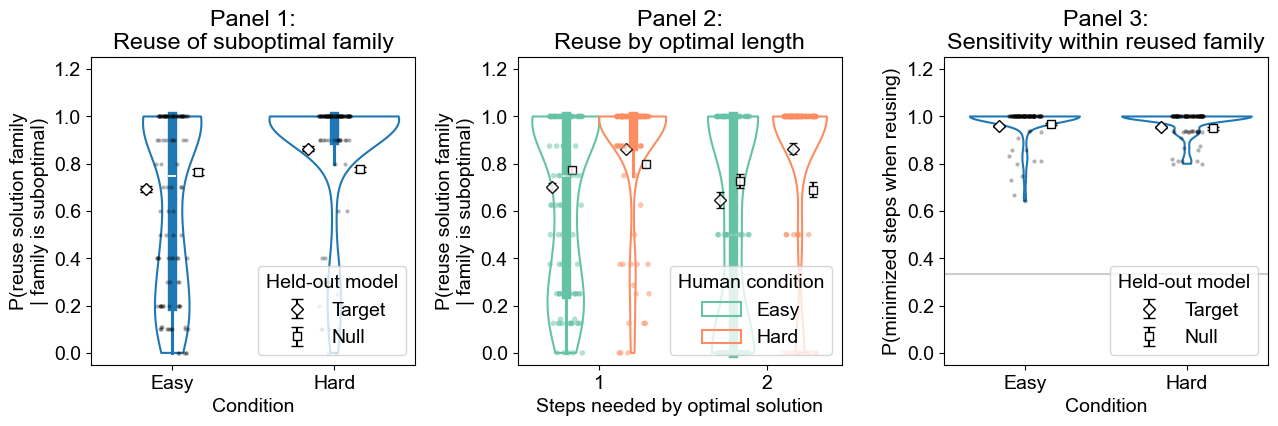

In [42]:
# ============================================================
# Experiment 2 held-out CV PPC overlay plot:
# Humans as violin plots;
# Target and Null model predictions as mean +/- SEM.
# ============================================================

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]

plt.rcParams.update({
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "font.size": 14,
})

cut = 0
inner = "box"
palette = "Set2"
point_size = 4

exp_cond_order = ["exp2color_0", "exp2visualsearch_1"]
exp_cond_labels = ["Easy", "Hard"]

mapping = {
    "exp2color_0": "Easy",
    "exp2visualsearch_1": "Hard",
}

model_order = ["Target", "Null"]

df_col2 = df_col2.copy()
df_col2["Condition"] = df_col2["exp_cond"].map(mapping)


def mean_sem(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return np.nan, np.nan

    if len(x) == 1:
        return np.mean(x), 0.0

    return np.mean(x), np.std(x, ddof=1) / np.sqrt(len(x))


def overlay_model_errorbars(
    ax,
    data,
    x,
    y,
    order,
    model_order=("Target", "Null"),
    dodge=0.16,
    markers=None,
    capsize=4,
):
    """
    Overlay held-out model predictions as mean +/- SEM.
    """
    if markers is None:
        markers = {"Target": "D", "Null": "s"}

    offsets = {
        model_order[0]: -dodge,
        model_order[1]: dodge,
    }

    x_pos = {v: i for i, v in enumerate(order)}

    for model_name in model_order:
        d_model = data[data["row_type"] == model_name].copy()

        xs = []
        means = []
        sems = []

        for x_level in order:
            vals = d_model.loc[d_model[x] == x_level, y].dropna().values
            m, se = mean_sem(vals)

            xs.append(x_pos[x_level] + offsets[model_name])
            means.append(m)
            sems.append(se)

        ax.errorbar(
            xs,
            means,
            yerr=sems,
            fmt=markers[model_name],
            linestyle="",
            capsize=capsize,
            color="k",
            markerfacecolor="white",
            markeredgecolor="k",
            label=model_name,
        )


fig, ax = plt.subplots(
    1, 3,
    figsize=(13, 13 / 2.9),
    sharey=False,
)


# ============================================================
# Panel 1
# ============================================================

d1_human = df_col1[df_col1["row_type"] == "Humans"].copy()
d1_model = df_col1[df_col1["row_type"].isin(model_order)].copy()

sns.violinplot(
    data=d1_human,
    y="plot_value",
    x="exp_cond",
    order=exp_cond_order,
    fill=False,
    inner=inner,
    cut=cut,
    ax=ax[0],
    color="C0",
)

sns.stripplot(
    data=d1_human,
    y="plot_value",
    x="exp_cond",
    order=exp_cond_order,
    alpha=0.3,
    size=3,
    ax=ax[0],
    dodge=True,
    color="k",
    legend=False,
)

overlay_model_errorbars(
    ax=ax[0],
    data=d1_model,
    x="exp_cond",
    y="plot_value",
    order=exp_cond_order,
    model_order=model_order,
)

ax[0].set_ylim([-0.05, 1.25])
ax[0].set_xlim([-0.5, 1.5])
ax[0].set_xlabel("Condition")
ax[0].set_xticks(np.arange(len(exp_cond_order)))
ax[0].set_xticklabels(exp_cond_labels)
ax[0].set_ylabel("P(reuse solution family\n| family is suboptimal)")
ax[0].set_title("Panel 1:\nReuse of suboptimal family")
ax[0].legend(title="Held-out model", frameon=True, loc="lower right")


# ============================================================
# Panel 2
# ============================================================

d2_human = df_col2[df_col2["row_type"] == "Humans"].copy()
d2_model = df_col2[df_col2["row_type"].isin(model_order)].copy()

sns.violinplot(
    data=d2_human,
    x="optimal_sol_len",
    y="plot_value",
    hue="Condition",
    fill=False,
    inner=inner,
    cut=cut,
    ax=ax[1],
    palette=palette,
    legend=True,
)

sns.stripplot(
    data=d2_human,
    x="optimal_sol_len",
    y="plot_value",
    hue="Condition",
    alpha=0.5,
    size=point_size,
    ax=ax[1],
    legend=False,
    dodge=True,
    jitter=0.2,
    palette=palette,
)

x_levels = sorted(d2_human["optimal_sol_len"].dropna().unique())
x_pos = {v: i for i, v in enumerate(x_levels)}

cond_offsets = {
    "exp2color_0": -0.22,
    "exp2visualsearch_1": 0.22,
}

model_offsets = {
    "Target": -0.06,
    "Null": 0.06,
}

model_markers = {
    "Target": "D",
    "Null": "s",
}

for (model_name, exp_cond, opt_len), g in d2_model.groupby(
    ["row_type", "exp_cond", "optimal_sol_len"]
):
    mean, se = mean_sem(g["plot_value"])

    xpos = (
        x_pos[opt_len]
        + cond_offsets.get(exp_cond, 0.0)
        + model_offsets.get(model_name, 0.0)
    )

    ax[1].errorbar(
        xpos,
        mean,
        yerr=se,
        marker=model_markers.get(model_name, "o"),
        linestyle="",
        color="k",
        markerfacecolor="white",
        markeredgecolor="k",
        capsize=3,
        markersize=6,
        alpha=0.9,
    )

ax[1].set_ylim([-0.05, 1.25])
ax[1].set_xlabel("Steps needed by optimal solution")
ax[1].set_ylabel("P(reuse solution family\n| family is suboptimal)")
ax[1].set_title("Panel 2:\nReuse by optimal length")
sns.move_legend(ax[1], "lower right", frameon=True, title="Human condition")


# ============================================================
# Panel 3
# ============================================================

d3_human = df_col3[df_col3["row_type"] == "Humans"].copy()
d3_model = df_col3[df_col3["row_type"].isin(model_order)].copy()

sns.violinplot(
    data=d3_human,
    x="exp_cond",
    y="plot_value",
    order=exp_cond_order,
    cut=cut,
    inner=inner,
    fill=False,
    ax=ax[2],
)

sns.stripplot(
    data=d3_human,
    x="exp_cond",
    y="plot_value",
    order=exp_cond_order,
    dodge=True,
    color="k",
    alpha=0.3,
    size=3,
    legend=False,
    ax=ax[2],
)

overlay_model_errorbars(
    ax=ax[2],
    data=d3_model,
    x="exp_cond",
    y="plot_value",
    order=exp_cond_order,
    model_order=model_order,
)

ax[2].plot([-1, 2], [1/3, 1/3], "k-", alpha=0.2)
ax[2].set_xlim([-0.5, 1.5])
ax[2].set_ylim([-0.05, 1.25])
ax[2].set_ylabel("P(minimized steps when reusing)")
ax[2].set_xlabel("Condition")
ax[2].set_xticks(np.arange(len(exp_cond_order)))
ax[2].set_xticklabels(exp_cond_labels)
ax[2].set_title("Panel 3:\nSensitivity within reused family")
ax[2].legend(title="Held-out model", frameon=True, loc="lower right")


fig.tight_layout()

# plt.savefig(
#     os.path.join(figpath, f"exp2_humans_violin_models_errorbars_heldout_{PRED_MODE}_{PARTICIPANT_MODE}.pdf"),
#     bbox_inches="tight",
# )

plt.show()

Bayes Factor BF10: 1.5364156145826075e+104
Bayes Factor BF10: 9.982370609669456e+117
Bayes Factor BF10: 1.8882909990623603e+117
Bayes Factor BF10: 3.1178990238953116e+117
Bayes Factor BF10: 2.1589447653007074e+122
Bayes Factor BF10: 2.514404045130444e+105


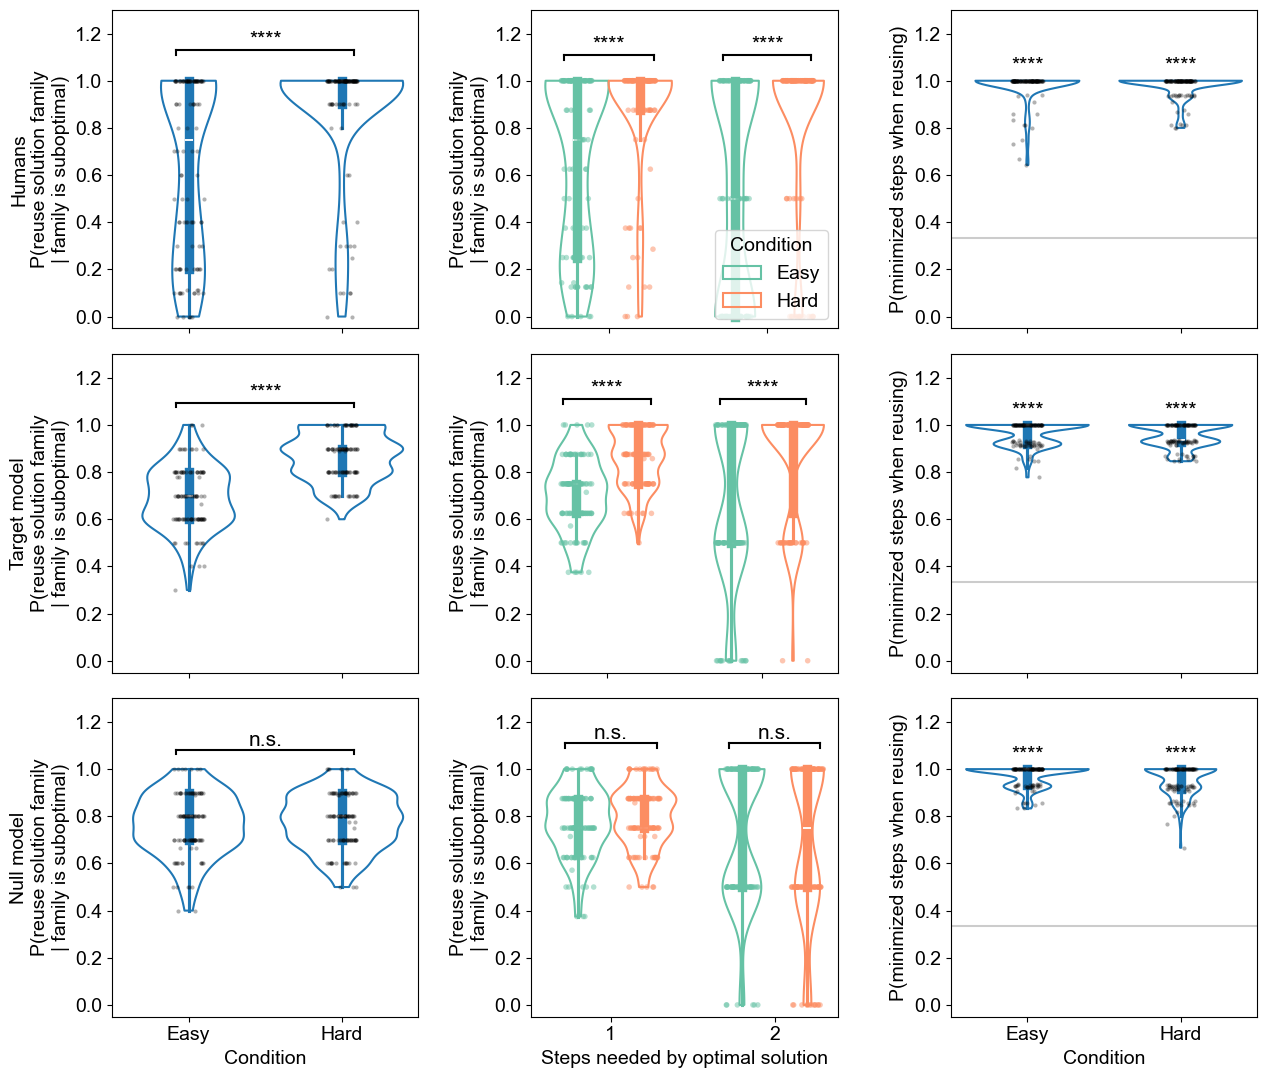

In [43]:
# ============================================================
# Experiment 2 held-out CV PPC:
# 3 rows x 3 columns, with significance stars
# ============================================================

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]

plt.rcParams.update({
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "font.size": 14,
})

cut = 0
inner = "box"
palette = "Set2"
point_size = 4

row_order = ["Humans", "Target", "Null"]

exp_cond_order = ["exp2color_0", "exp2visualsearch_1"]
exp_cond_labels = ["Easy", "Hard"]

mapping = {
    "exp2color_0": "Easy",
    "exp2visualsearch_1": "Hard",
}

df_col2 = df_col2.copy()
df_col2["Condition"] = df_col2["exp_cond"].map(mapping)

fig, ax = plt.subplots(
    3, 3,
    figsize=(13, 11),
    sharex=False,
    sharey=False,
)

for r, row_type in enumerate(row_order):
    # --------------------------------------------------------
    # Col 1: overall reuse on Einstellung trials
    # --------------------------------------------------------
    d1 = df_col1[df_col1["row_type"] == row_type].copy()

    sns.violinplot(
        data=d1,
        y="plot_value",
        x="exp_cond",
        order=exp_cond_order,
        fill=False,
        inner=inner,
        cut=cut,
        ax=ax[r, 0],
        color="C0",
    )

    sns.stripplot(
        data=d1,
        y="plot_value",
        x="exp_cond",
        order=exp_cond_order,
        alpha=0.3,
        size=3,
        ax=ax[r, 0],
        dodge=True,
        color="k",
        legend=False,
    )

    annotate_ind_violin_significance(
        ax=ax[r, 0],
        df=d1,
        x="exp_cond",
        y="plot_value",
        hue=None,
        comparisons=[
            (("exp2color_0", None), ("exp2visualsearch_1", None))
        ],
        paired=False,
        test="t",
        y_offset=0.12,
        cap_height=0.02,
        font_size=15,
        show="stars",
    )

    ax[r, 0].set_ylim([-0.05, 1.30])
    ax[r, 0].set_xlim([-0.5, 1.5])

    if r == 2:
        ax[r, 0].set_xlabel("Condition")
        ax[r, 0].set_xticks(np.arange(len(exp_cond_order)))
        ax[r, 0].set_xticklabels(exp_cond_labels)
    else:
        ax[r, 0].set_xlabel("")
        ax[r, 0].set_xticklabels("")

    if r == 0:
        ax[r, 0].set_ylabel(
            f"{row_type}\nP(reuse solution family\n| family is suboptimal)"
        )
    else:
        ax[r, 0].set_ylabel(
            f"{row_type} model\nP(reuse solution family\n| family is suboptimal)"
        )

    # --------------------------------------------------------
    # Col 2: reuse by optimal solution length
    # --------------------------------------------------------
    d2 = df_col2[df_col2["row_type"] == row_type].copy()

    sns.violinplot(
        data=d2,
        x="optimal_sol_len",
        y="plot_value",
        hue="Condition",
        fill=False,
        inner=inner,
        cut=cut,
        ax=ax[r, 1],
        palette=palette,
        legend=True,
    )

    sns.stripplot(
        data=d2,
        x="optimal_sol_len",
        y="plot_value",
        hue="Condition",
        alpha=0.5,
        size=point_size,
        ax=ax[r, 1],
        legend=False,
        dodge=True,
        jitter=0.2,
        palette=palette,
    )

    annotate_ind_violin_significance(
        ax=ax[r, 1],
        df=d2,
        x="optimal_sol_len",
        y="plot_value",
        hue="exp_cond",
        comparisons=("exp2color_0", "exp2visualsearch_1"),
        paired=False,
        test="t",
        y_offset=0.10,
        cap_height=0.02,
        font_size=15,
        debug=False,
        show="stars",
    )

    ax[r, 1].set_ylim([-0.05, 1.30])

    if r == 2:
        ax[r, 1].set_xlabel("Steps needed by optimal solution")
    else:
        ax[r, 1].set_xlabel("")
        ax[r, 1].set_xticklabels("")

    ax[r, 1].set_ylabel(
        "P(reuse solution family\n| family is suboptimal)"
    )

    if r == 0:
        sns.move_legend(ax[r, 1], "lower right", frameon=True, title="Condition")
    else:
        leg = ax[r, 1].get_legend()
        if leg is not None:
            leg.remove()

    # --------------------------------------------------------
    # Col 3: sensitivity within reused family
    # --------------------------------------------------------
    d3 = df_col3[df_col3["row_type"] == row_type].copy()

    sns.violinplot(
        data=d3,
        x="exp_cond",
        y="plot_value",
        order=exp_cond_order,
        cut=cut,
        inner=inner,
        fill=False,
        ax=ax[r, 2],
    )

    sns.stripplot(
        data=d3,
        x="exp_cond",
        y="plot_value",
        order=exp_cond_order,
        dodge=True,
        color="k",
        alpha=0.3,
        size=3,
        legend=False,
        ax=ax[r, 2],
    )

    ax[r, 2].plot([-1, 2], [1/3, 1/3], "k-", alpha=0.2)

    annotate_violin_significance(
        ax=ax[r, 2],
        df=d3,
        x="exp_cond",
        y="plot_value",
        hue=None,
        test="t",
        mu=1/3,
        y_offset=0.02,
        min_height_pad=-0.1,
        font_size=15,
        show="stars",
    )

    ax[r, 2].set_xlim([-0.5, 1.5])
    ax[r, 2].set_ylim([-0.05, 1.30])
    ax[r, 2].set_ylabel("P(minimized steps when reusing)")

    if r == 2:
        ax[r, 2].set_xlabel("Condition")
        ax[r, 2].set_xticks(np.arange(len(exp_cond_order)))
        ax[r, 2].set_xticklabels(exp_cond_labels)
    else:
        ax[r, 2].set_xlabel("")
        ax[r, 2].set_xticklabels("")


fig.tight_layout()

plt.savefig(
    os.path.join(figpath, f"exp2_humans_target_null_ppc_3x3_heldout_{PRED_MODE}_{PARTICIPANT_MODE}.pdf"),
    bbox_inches="tight",
)

plt.show()